# Introduction
Günümüzde mobil uygulama mağazalarında bir uygulamanın başarısı **genellikle** ortalama puanı, indirme sayısı ve yorum sayısı gibi yüzeysel metrikler üzerinden değerlendirilmektedir. Ancak bu ham metrikler tek başına uygulamanın gerçek kalitesini ve kullanıcı memnuniyetini yansıtmakta çoğunlukla yetersizdir:

* **Manipülasyona Açık Ham Puanlar:** Yalnızca birkaç kullanıcı tarafından 5.0 puan verilmiş yeni veya az yorumlu bir uygulama, yüz binlerce yoruma sahip 4.5 puanlık köklü bir uygulamanın haksız şekilde önüne geçebilmektedir.
* **Kategori Dinamikleri ve Tolerans Farkı:** Oyun (Game) ve genel Uygulama (Utility/Finance/Social) kullanıcılarının hata toleransları, beklentileri ve puanlama eğilimleri birbirinden tamamen farklı dinamiklere sahiptir.
* **Puan ve Duygu Uyuşmazlığı (Sentiment Mismatch):** Kullanıcılar mağazada sesini duyurmak veya yorumunu öne çıkarmak için taktiksel olarak 5 yıldız seçip içine ağır teknik şikayetler yazabilmekte; ya da çok sevdikleri bir uygulamaya tek bir sürüm hatası yüzünden 1 yıldız kırabilmektedir.

Gerçek uygulama mağazalarında modern sıralama sistemleri yalnızca aritmetik ortalamaya bakmaz; kullanıcı sayısı, yorum hacmi, yorumların metin içeriği, güncellik, güvenilirlik ve kullanıcı memnuniyeti gibi birçok farklı sinyali birlikte işler. Bu yaklaşım veri bilimi alanında **Ölçümleme Problemleri (Measurement Problems)** olarak adlandırılır. Ölçümleme problemleri; bir ürünün, hizmetin veya içeriğin değerini en güvenilir, manipülasyondan uzak ve adil şekilde skorlayıp sıralamayı amaçlayan matematiksel ve algoritmik yöntemleri kapsar.

Bu projede, **1 Milyondan fazla (1.05M+) gerçek Google Play Store yorumu ve uygulama verisi** kullanılarak çok boyutlu bir değerlendirme, sıralama ve duygu zekası sistemi oluşturulmuştur. Amaç yalnızca ortalama puanları hesaplamak değil; 

1. **Bayesian Average Rating (BAR)** ve çok faktörlü hibrit modeller ile manipülasyona kapalı ürün ve yorum sıralama mimarisi kurmak,
2. **A/B Hipotez Testleri (Mann-Whitney U)** ile kategori bazlı kullanıcı tolerans farklarını matematiksel olarak doğrulamak,
3. **VADER NLP ve N-Gram Metin Madenciliği** ile puan-duygu çelişkilerini (gizli şikayetleri ve sürüm tepkilerini) saptayarak ürün ekipleri için aksiyon odaklı bir karar destek altyapısı sunmaktır.

## Bu Projede Neler Öğreneceğiz?
Bu çalışma yalnızca temel bir betimsel veri analizi yapmak amacıyla değil; uygulama mağazaları, e-ticaret platformları ve öneri sistemleri gibi büyük ölçekli dijital platformlarda kullanılan derecelendirme ve sıralama mimarisinin matematiksel mantığını kavramak için tasarlanmıştır. Gerçek dünya sistemleri tek bir yüzeysel metrik yerine çok boyutlu sinyalleri işler. Bu doğrultuda proje boyunca **Ölçümleme Problemleri (Measurement Problems)**, **İstatistiki Hipotez Testleri** ve **Doğal Dil İşleme (NLP)** teknikleri entegre bir biçimde uygulanacaktır.

Proje süresince aşağıdaki temel başlıklar üzerinde derinlemesine pratik yapılması hedeflenmektedir:

* **İleri Düzey Puanlama ve Sıralama Mimarisi (Rating & Sorting):**
  * **Bayesian Average Rating (BAR):** Yıldız dağılımlarını ve güvenilirlik aralıklarını hesaba katan, düşük hacimli manipülasyonları engelleyen Bayesçi skorlama.
  * **Çok Faktörlü Hibrit Skorlama:** İndirme hacmi, güncellik (time-decay), yorum sayısı ve faydalılık (*helpful votes*) sinyallerini ölçeklendirerek (scaling) ürün sıralama algoritması oluşturma.

* **İstatistiki Çıkarım ve Hipotez Testi (A/B Testing):**
  * Normallik varsayımı kontrolü (Shapiro-Wilk) ve parametrik olmayan **Mann-Whitney U Testi** ile Uygulama (App) ve Oyun (Game) kategorileri arasındaki kullanıcı tolerans farkının matematiksel doğrulanması ($p < 0.05$).

* **NLP ile Duygu Analizi & Anomali Tespiti (Sentiment Intelligence):**
  * **VADER Sentiment Analysis:** Yorum metinlerinin anlamsal polarite skorları (`compound`) ile verilen yıldız puanları arasındaki tezatlıkların tespiti.
  * **Puan-Duygu Çelişkisi Madenciliği:** Mağazada görünürlük kazanmak için 5 yıldız verilerek yazılan "Gizli Şikayetlerin" (*Hidden Complaints*) ve güncelleme tepkisi veren sadık kullanıcıların saptanması.

* **Kök Neden Analizi (Root Cause Mining):**
  * N-Gram / Bigram frekans çıkarımları ile düşük puanlı yorumlardaki teknik arıza ve ürün açıklarının sistematik olarak gruplanması.

* **Aksiyon Odaklı Karar Destek & Ürün Yönetimi:**
  * Çıkarılan analitik içgörülerin **P1 Kritik Destek Triyajı**, **Kademeli Sürüm Dağıtımı (Phased Rollout)** ve kullanıcı kazanım stratejilerine dönüştürülmesi.

# Veri Seti Hakkında
Bu projede kullanılan veri seti, Google Play Market platformundan toplanmış uygulama ve oyun bilgileri ile kullanıcı yorumlarını içeren temizlenmiş ve analiz için hazırlanmış bir veri setidir. Veri seti içerisinde toplamda 1 milyondan fazla kullanıcı yorumu, 335 oyun ve 217 mobil uygulamaya ait detaylı metadata bilgileri bulunmaktadır. Veri setinin hem sayısal hem de metin verisi içermesi, ölçümleme problemleri, duygu analizi ve sıralama algoritmaları gibi farklı veri bilimi tekniklerini birlikte uygulamaya uygun bir yapı sunmaktadır.

Veri seti dört ayrı CSV dosyasından oluşmaktadır:
* `apps_info.csv`

* `apps_reviews.csv`

* `games_info.csv`

* `games_reviews.csv`


Bu dosyalar uygulamalar ve oyunlar için ayrı tutulmuş olup, her biri farklı seviyede bilgiler içermektedir. Bu sayede hem uygulama seviyesinde hem de kullanıcı yorumu seviyesinde analiz yapılabilmektedir.

###  `apps_info.csv`
Bu dosya mobil uygulamalara ait metadata bilgilerini içermektedir. Uygulama bazlı analizlerde kullanılacak temel dosyalardan biridir.

Dosyada bulunan başlıca sütunlar şunlardır:

- app_id → Uygulama için benzersiz kimlik

- app_name → Uygulamanın adı

- description → Temizlenmiş uygulama açıklaması

- score → Ortalama kullanıcı puanı (0–5 arası)

- ratings_count → Uygulamaya verilen oy sayısı

- downloads → İndirme sayısı

- content_rating → Yaş grubu bilgisi (Everyone, Teen vb.)

- section → Uygulama kategorisi

- categories → Virgülle ayrılmış alt kategori / etiket bilgileri

Bu bilgiler uygulamaların genel performansını değerlendirmek için kullanılacaktır. Özellikle ortalama puan, oy sayısı ve indirme sayısı gibi değişkenler alternatif puanlama ve sıralama yöntemleri oluştururken önemli rol oynayacaktır.

### `apps_reviews.csv`
Bu dosya mobil uygulamalara ait kullanıcı yorumlarını içermektedir. Yorum bazlı analizlerde kullanılacaktır.

Dosyada bulunan sütunlar:

* app_id → apps_info.csv ile bağlantı kurmak için kullanılır

* review_text → Kullanıcı yorumu (temizlenmiş metin)

* review_score → Kullanıcının verdiği yıldız puanı (1–5)

* review_date → Yorum tarihi

* helpful_count → Yorumun aldığı beğeni / faydalı oy sayısı

Bu dosya sayesinde kullanıcı geri bildirimleri detaylı şekilde incelenebilir. Yorum metinleri kullanılarak duygu analizi yapılabilir, yorumların ne kadar bilgilendirici olduğu ölçülebilir ve kullanıcıların en çok şikayet ettiği konular tespit edilebilir.

### `games_info.csv`
Bu dosya oyun kategorisindeki uygulamalara ait metadata bilgilerini içermektedir. Yapı olarak apps_info.csv dosyasına benzer olup yalnızca oyunları kapsar.

Dosyada bulunan sütunlar:

* game_id → Oyun için benzersiz kimlik

* game_name → Oyunun adı

* description → Oyun açıklaması

* score → Ortalama kullanıcı puanı

* ratings_count → Oy sayısı

* downloads → İndirme sayısı

* content_rating → Yaş grubu bilgisi

* section → Oyun kategorisi

* categories → Tür etiketleri

Bu dosya uygulamalar ve oyunlar arasında karşılaştırma yapmak veya tüm platformu birlikte analiz etmek için kullanılacaktır.

### `games_reviews.csv`
Bu dosya oyunlara ait kullanıcı yorumlarını içermektedir. Yapı olarak apps_reviews.csv ile aynıdır ancak yalnızca oyun kategorisine ait yorumları kapsar.

Dosyada bulunan sütunlar:

* game_id → games_info.csv ile bağlantı kurmak için kullanılır

* review_text → Kullanıcı yorumu

* review_score → Yıldız puanı

* review_date → Yorum tarihi

* helpful_count → Yorumun aldığı faydalı oy sayısı

Bu dosya kullanıcı memnuniyetini analiz etmek, duygu analizi yapmak ve yorumların bilgi değerini ölçmek için kullanılacaktır.


# Data Loading
Projeye başlarken veri setlerini doğrudan birleştirmek yerine önce tek tek inceleyerek ilerlemeyi tercih ettim.
Bu aşamada amacım sadece veri setlerini yüklemek ve genel yapılarını görmek.  
Henüz merge işlemi yapmayacağım. Çünkü önce hangi sütunların gerekli olduğunu, hangi değişkenleri kullanacağımı ve veri setlerinin birbirine nasıl bağlanacağını anlamak istiyorum. Bundan dolayı ilk adım olarak tüm dosyaları yükleyip inceleyeceğim.

In [87]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math
import scipy.stats as st
from sklearn.preprocessing import MinMaxScaler

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/games_reviews.csv
/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/games_info.csv
/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/apps_reviews.csv
/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/apps_info.csv


In [88]:
apps_info = pd.read_csv("/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/apps_info.csv")
apps_reviews = pd.read_csv("/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/apps_reviews.csv")
games_info = pd.read_csv("/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/games_info.csv")
games_reviews = pd.read_csv("/kaggle/input/datasets/dmytrobuhai/play-market-2025-1m-reviews-500-titles/games_reviews.csv")

## apps_info  inceleme

In [89]:
apps_info.head()

,app_id,app_name,description,score,ratings_count,downloads,content_rating,section,categories
0,1,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance
1,2,"Priceline: Hotel, Flight & Car",Save on your next trip with exclusive deals on...,4.7,502000,10000000,Everyone,Business tools,Travel & Local
2,3,Slack,Slack brings team communication and collaborat...,3.4,134000,10000000,Everyone,Business tools,Business
3,4,MyWalmart,"Introducing MyWalmart, the one app designed fo...",4.7,211000,1000000,Everyone,Business tools,Business
4,5,Fidelity Investments,Invest at a firm invested in you. Fidelity’s s...,4.6,182000,5000000,Everyone,Business tools,Finance


In [90]:
apps_info.shape

(217, 9)

In [91]:
apps_info.columns

Index(['app_id', 'app_name', 'description', 'score', 'ratings_count',
       'downloads', 'content_rating', 'section', 'categories'],
      dtype='object')

In [92]:
apps_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          217 non-null    int64  
 1   app_name        217 non-null    object 
 2   description     217 non-null    object 
 3   score           217 non-null    float64
 4   ratings_count   217 non-null    int64  
 5   downloads       217 non-null    int64  
 6   content_rating  217 non-null    object 
 7   section         217 non-null    object 
 8   categories      217 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 15.4+ KB


In [93]:
apps_info.isnull().sum()

app_id            0
app_name          0
description       0
score             0
ratings_count     0
downloads         0
content_rating    0
section           0
categories        0
dtype: int64

In [94]:
apps_info.describe().T

,count,mean,std,min,25%,50%,75%,max
app_id,217.0,1.090000e+02,6.278668e+01,1.0,55.0,109.0,163.0,2.170000e+02
score,217.0,4.405069e+00,4.264649e-01,1.9,4.3,4.5,4.7,4.900000e+00
ratings_count,217.0,2.803914e+06,8.065644e+06,6140.0,188000.0,565000.0,2130000.0,1.010000e+08
downloads,217.0,3.895668e+08,1.261960e+09,1000000.0,10000000.0,10000000.0,100000000.0,1.000000e+10


## apps_reviews inceleme

In [95]:
apps_reviews.head()

,app_id,review_text,review_score,review_date,helpful_count
0,1,I don't know what happened to this app. It was...,1,2025-04-03,6
1,1,app was good. then the randomly locked my acco...,1,2025-04-13,3
2,1,Terrible user interface 🤬 Menus cluttered. App...,1,2025-03-17,48
3,1,I got this app to send money quickly without h...,1,2025-02-01,23
4,1,You're honestly better off using another app o...,1,2024-12-19,22


In [96]:
apps_reviews.shape

(466700, 5)

In [97]:
apps_reviews.columns

Index(['app_id', 'review_text', 'review_score', 'review_date',
       'helpful_count'],
      dtype='object')

In [98]:
apps_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466700 entries, 0 to 466699
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   app_id         466700 non-null  int64 
 1   review_text    466700 non-null  object
 2   review_score   466700 non-null  int64 
 3   review_date    466700 non-null  object
 4   helpful_count  466700 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 17.8+ MB


In [99]:
apps_reviews.isnull().sum()

app_id           0
review_text      0
review_score     0
review_date      0
helpful_count    0
dtype: int64

In [100]:
apps_reviews.describe().T

,count,mean,std,min,25%,50%,75%,max
app_id,466700.0,83.638290,69.396137,1.0,14.0,58.0,140.0,217.0
review_score,466700.0,2.973788,1.508177,1.0,1.0,3.0,4.0,5.0
helpful_count,466700.0,13.545132,179.613284,0.0,0.0,0.0,2.0,25518.0


## games_info inceleme

In [101]:
games_info.head()

,game_id,game_name,description,score,ratings_count,downloads,content_rating,section,categories
0,1,Geometry Dash SubZero,Geometry Dash is back with a brand new adventu...,4.5,926000,100000000,Everyone,Abstract graphics,"Action, Platformer, Runner, Arcade, Single pla..."
1,2,Word Collect - Word Games Fun,Download the best word games Free in Word Coll...,4.7,588000,10000000,Everyone,Abstract graphics,"#10 top grossing word, Word, Search, Single pl..."
2,3,Tap Away,Do you have what it takes to solve all the swi...,4.3,1130000,50000000,Everyone,Abstract graphics,"Puzzle, Logic, Casual, Single player, Abstract..."
3,4,Sudoku - Classic Sudoku Puzzle,Enjoy the Classic Sudoku Puzzle Game for free!...,4.7,2650000,50000000,Everyone,Abstract graphics,"Puzzle, Logic, Sudoku, Casual, Single player, ..."
4,5,Woodber - Classic Number Game,Woodber - perfect combination of classic numbe...,4.6,225000,10000000,Everyone,Abstract graphics,"Puzzle, Logic, Casual, Single player, Abstract..."


In [102]:
games_info.shape

(335, 9)

In [103]:
games_info.columns

Index(['game_id', 'game_name', 'description', 'score', 'ratings_count',
       'downloads', 'content_rating', 'section', 'categories'],
      dtype='object')

In [104]:
games_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   game_id         335 non-null    int64  
 1   game_name       335 non-null    object 
 2   description     335 non-null    object 
 3   score           335 non-null    float64
 4   ratings_count   335 non-null    int64  
 5   downloads       335 non-null    int64  
 6   content_rating  335 non-null    object 
 7   section         335 non-null    object 
 8   categories      335 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 23.7+ KB


In [105]:
games_info.isnull().sum()

game_id           0
game_name         0
description       0
score             0
ratings_count     0
downloads         0
content_rating    0
section           0
categories        0
dtype: int64

In [106]:
games_info.describe().T

,count,mean,std,min,25%,50%,75%,max
game_id,335.0,1.680000e+02,9.685040e+01,1.0,84.5,168.0,251.5,3.350000e+02
score,335.0,4.425970e+00,3.455624e-01,2.5,4.3,4.5,4.6,5.000000e+00
ratings_count,335.0,1.336289e+06,3.657874e+06,58.0,37950.0,189000.0,1040000.0,4.280000e+07
downloads,335.0,5.558720e+07,1.430595e+08,1000.0,1000000.0,10000000.0,50000000.0,1.000000e+09


## games_reviews inceleme

In [107]:
games_reviews.head()

,game_id,review_text,review_score,review_date,helpful_count
0,1,"too many ads for a game where you die a lot, g...",1,2025-04-13,2
1,1,I really love this game and its music. But at ...,1,2023-07-28,3963
2,1,The app is cool in general. BUT this is meant ...,1,2024-11-04,24
3,1,I'm gonna say I hate this game so much! Ads al...,1,2020-11-13,158
4,1,"This game is great, except.... It has 30 secon...",1,2019-02-28,73


In [108]:
games_reviews.shape

(583170, 5)

In [109]:
games_reviews.columns

Index(['game_id', 'review_text', 'review_score', 'review_date',
       'helpful_count'],
      dtype='object')

In [110]:
games_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583170 entries, 0 to 583169
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   game_id        583170 non-null  int64 
 1   review_text    583170 non-null  object
 2   review_score   583170 non-null  int64 
 3   review_date    583170 non-null  object
 4   helpful_count  583170 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 22.2+ MB


In [111]:
games_reviews.isnull().sum()

game_id          0
review_text      0
review_score     0
review_date      0
helpful_count    0
dtype: int64

In [112]:
games_reviews.describe().T

,count,mean,std,min,25%,50%,75%,max
game_id,583170.0,143.599643,89.428723,1.0,56.0,140.0,220.0,335.0
review_score,583170.0,3.129635,1.481319,1.0,2.0,3.0,5.0,5.0
helpful_count,583170.0,48.328897,1903.641507,0.0,0.0,1.0,4.0,544240.0


# Data Understanding

Veri setlerini yükledikten sonra hemen birleştirmek yerine önce veriyi daha yakından tanımak istiyorum. Bu yüzden bu aşamada veri setlerinin dağılımlarını inceleyerek bazı sorulara cevap arayacağım.

Bakmak istediğim şeyler:

- score dağılımı nasıl?
- ratings_count nasıl dağılmış?
- downloads çok dengesiz mi?
- review_score genelde kaç geliyor?
- helpful_count çoğunlukla 0 mı?
- çok az oy alan ama yüksek puanlı uygulamalar var mı?
- çok indirilen ama düşük puanlı uygulamalar var mı?

Bu soruların cevaplarının , ortalama puanın neden tek başına yeterli olmadığını göstermesini bekliyorum.

In [113]:
apps_info["score"].describe()

count    217.000000
mean       4.405069
std        0.426465
min        1.900000
25%        4.300000
50%        4.500000
75%        4.700000
max        4.900000
Name: score, dtype: float64

In [114]:
apps_info["ratings_count"].describe()

count    2.170000e+02
mean     2.803914e+06
std      8.065644e+06
min      6.140000e+03
25%      1.880000e+05
50%      5.650000e+05
75%      2.130000e+06
max      1.010000e+08
Name: ratings_count, dtype: float64

In [115]:
apps_info["downloads"].describe()

count    2.170000e+02
mean     3.895668e+08
std      1.261960e+09
min      1.000000e+06
25%      1.000000e+07
50%      1.000000e+07
75%      1.000000e+08
max      1.000000e+10
Name: downloads, dtype: float64

In [116]:
apps_reviews["review_score"].value_counts()

review_score
1    117666
5    106471
4     87741
2     77584
3     77238
Name: count, dtype: int64

In [117]:
apps_reviews["helpful_count"].describe()

count    466700.000000
mean         13.545132
std         179.613284
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max       25518.000000
Name: helpful_count, dtype: float64

In [118]:
apps_reviews["review_length"] = apps_reviews["review_text"].str.len()

apps_reviews["review_length"].describe()

count    466700.000000
mean        179.367073
std         141.392567
min           3.000000
25%          67.000000
50%         142.000000
75%         260.000000
max        4024.000000
Name: review_length, dtype: float64

In [119]:
sns.set_theme(style="whitegrid", palette="deep")

def plot_distribution(df, col, log=False):

    plt.figure(figsize=(8,5))

    if log:
        sns.histplot(np.log1p(df[col]), bins=50)
        plt.title(f"{col} distribution (log)")
        plt.xlabel(f"log({col})")

    else:
        sns.histplot(df[col], bins=50)
        plt.title(f"{col} distribution")
        plt.xlabel(col)

    plt.ylabel("Count")
    plt.show()

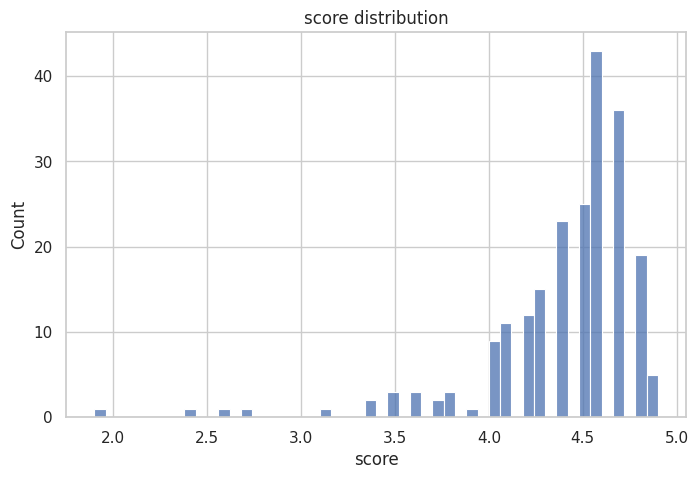

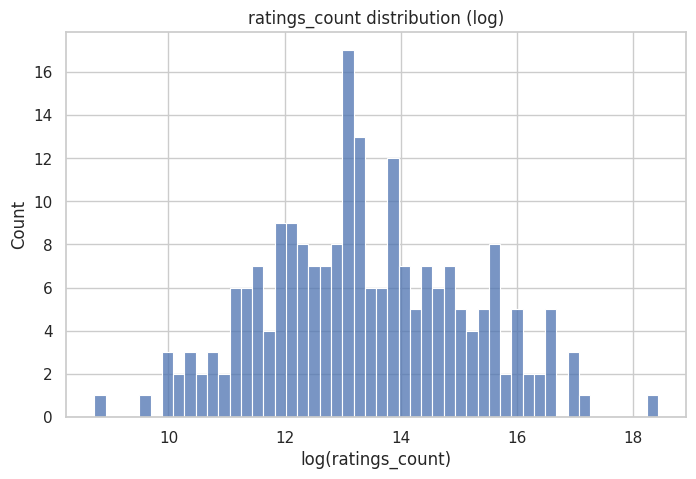

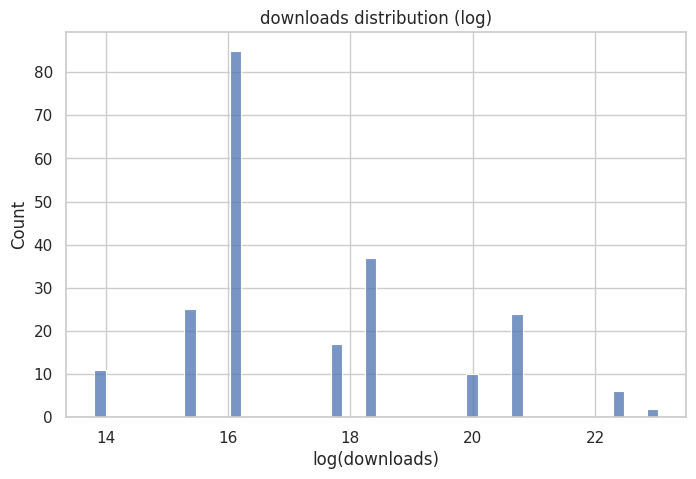

In [120]:
cols_info = [
    ("score", False),
    ("ratings_count", True),
    ("downloads", True),
]

for col, lg in cols_info:
    plot_distribution(apps_info, col, log=lg)

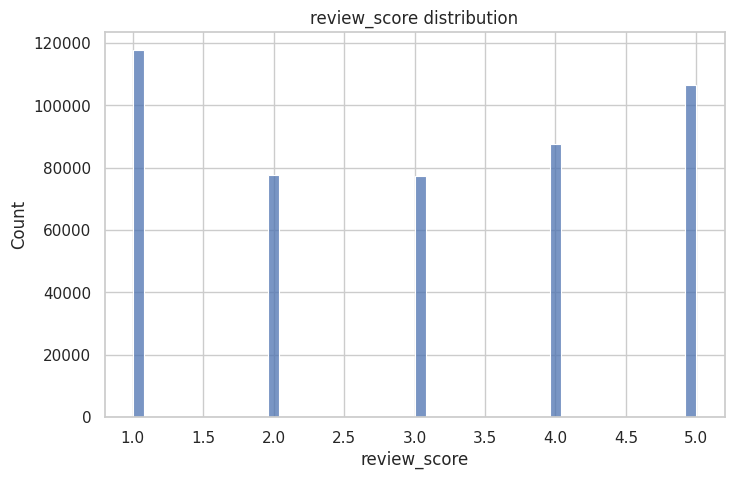

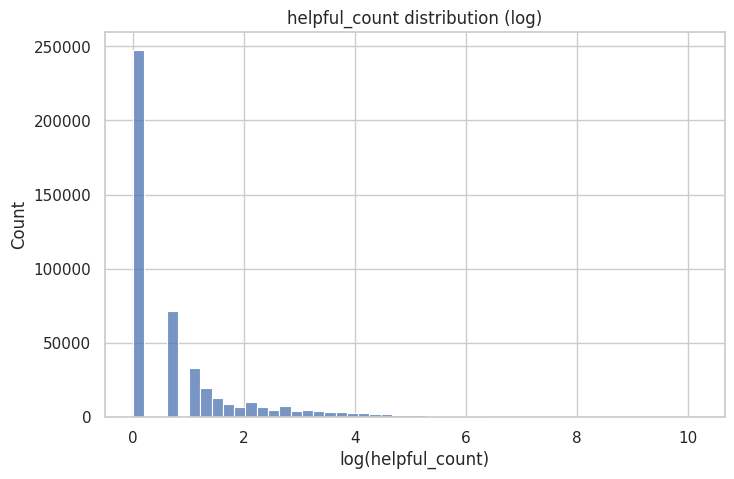

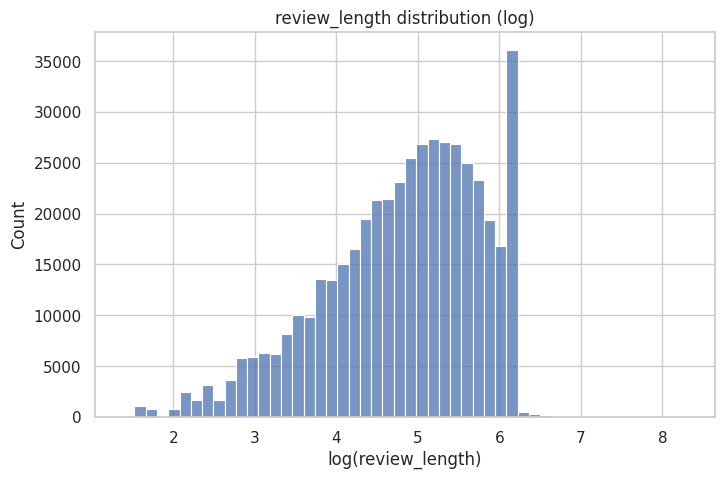

In [121]:
cols_reviews = [
    ("review_score", False),
    ("helpful_count", True),
    ("review_length", True),
]

for col, lg in cols_reviews:
    plot_distribution(apps_reviews, col, log=lg)

Veri setinin dağılımlarını incelerken ortalama puanın tek başına yeterli olmayacağını zaten tahmin ediyordum. Elde ettiğim sonuçlar da bu durumu açık şekilde gösterdi.

Öncelikle **score** değişkenine baktığımda uygulamaların büyük kısmının zaten yüksek puan aldığını gördüm. Ortalama yaklaşık 4.4 ve çoğu uygulama 4.3 ile 4.7 arasında. Bu da kullanıcıların genelde yüksek puan verme eğiliminde olduğunu gösteriyor. Böyle bir durumda sadece ortalama puana bakarak uygulamaları sıralamak çok anlamlı olmayabilir.

**ratings_count** değerlerine baktığımda uygulamalar arasında çok büyük farklar olduğunu gördüm. Bazı uygulamalar çok az oy almışken bazıları milyonlarca oy almış. Bu da şu soruyu aklıma getirdi: 4.9 puan almış ama 50 oy alan bir uygulama mı daha iyi, yoksa 4.6 puan almış ama milyonlarca oy alan bir uygulama mı? Bu yüzden oy sayısını da dikkate alan bir puanlama yapmak gerektiğini düşündüm.

**downloads** dağılımına baktığımda da benzer bir durum gördüm. İndirme sayıları çok dengesiz. Bazı uygulamalar milyarlarca indirilmişken bazıları çok daha az kullanıcıya ulaşmış. Bu da uygulamanın popülerliğini gösteren önemli bir sinyal olabilir.

Yorum tarafına baktığımda **review_score** dağılımında kullanıcıların çoğunlukla yüksek puan verdiğini gördüm. Bu da ortalama puanın çoğu uygulama için birbirine yakın çıkmasına neden olabilir. Bu yüzden sadece puana bakmak yerine yorumları da incelemek gerektiğini düşündüm.

**helpful_count** değerlerine baktığımda yorumların büyük bir kısmının hiç oy almadığını, ama bazı yorumların çok yüksek sayıda faydalı oyu aldığını gördüm. Bu da her yorumun aynı derecede güvenilir olmadığını gösteriyor. Daha faydalı bulunan yorumların değerlendirmede daha fazla ağırlık alması gerektiğini düşünüyorum.

**review_length** değerlerine baktığımda ise yorum uzunluklarının çok değişken olduğunu gördüm. Bazı yorumlar çok kısa, bazıları ise oldukça uzun. Daha uzun yorumlar genelde daha fazla bilgi içerdiği için yorum kalitesini ölçerken kullanılabilecek bir özellik olabilir.

Bu gözlemlerden sonra ortalama puanın tek başına yeterli olmadığına karar verdim. Daha doğru bir değerlendirme yapabilmek için oy sayısını, indirme sayısını, yorumları ve yorumların kalitesini birlikte kullanarak yeni bir ranking sistemi oluşturmaya çalışacağım.

Bir sonraki adımda veri setlerini birleştirerek analiz için tek bir tablo oluşturacağım.

# Data Preparation
Başlangıçta uygulamalar ve oyunlar ayrı dosyalar halinde verilmişti. Aynı şekilde yorumlar da ayrı tutuluyordu. Ancak measurement problems üzerinde çalışabilmek için tüm verileri tek bir yapı altında toplamak daha mantıklı olacak.

Bu yüzden bu aşamada:

- uygulama ve oyun bilgilerini birleştireceğim
- uygulama ve oyun yorumlarını birleştireceğim
- daha sonra bu iki tabloyu merge ederek tek bir veri seti oluşturacağım

Bu sayede hem uygulama bilgilerini hem de kullanıcı yorumlarını birlikte kullanarak daha gerçekçi bir puanlama ve sıralama sistemi kurabileceğim.

In [122]:
# -----------------------
# INFO TABLES
# -----------------------

df_apps = apps_info.copy()
df_games = games_info.copy()

df_apps["product_type"] = "app"
df_games["product_type"] = "game"

df_apps = df_apps.rename(columns={
    "app_id": "id",
    "app_name": "product_name"
})

df_games = df_games.rename(columns={
    "game_id": "id",
    "game_name": "product_name"
})

df_info = pd.concat(
    [df_apps, df_games],
    ignore_index=True
)

print("df_info shape:", df_info.shape)


# -----------------------
# REVIEW TABLES
# -----------------------

df_app_reviews = apps_reviews.copy()
df_game_reviews = games_reviews.copy()

df_app_reviews["product_type"] = "app"
df_game_reviews["product_type"] = "game"

df_app_reviews = df_app_reviews.rename(columns={"app_id": "id"})
df_game_reviews = df_game_reviews.rename(columns={"game_id": "id"})

df_reviews = pd.concat(
    [df_app_reviews, df_game_reviews],
    ignore_index=True
)

print("df_reviews shape:", df_reviews.shape)


# -----------------------
# MERGE
# -----------------------

df_products = df_reviews.merge(
    df_info,
    on=["id", "product_type"],
    how="left"
)

print("df_products shape:", df_products.shape)


# -----------------------
# REVIEW LENGTH
# -----------------------

df_products["review_length"] = df_products["review_text"].str.len()


df_info shape: (552, 10)
df_reviews shape: (1049870, 7)
df_products shape: (1049870, 15)


## Final Dataset Check

In [123]:
def check_df(df):

    print("Shape")
    print(df.shape)

    print("\nColumns")
    print(df.columns)

    print("\nInfo")
    print(df.info())

    print("\nMissing")
    print(df.isnull().sum())

    print("\nDescribe")
    display(df.describe().T)

    print("\nHead")
    display(df.head())
    
    print("\nTail")
    display(df.tail())


check_df(df_products)

Shape
(1049870, 15)

Columns
Index(['id', 'review_text', 'review_score', 'review_date', 'helpful_count',
       'review_length', 'product_type', 'product_name', 'description', 'score',
       'ratings_count', 'downloads', 'content_rating', 'section',
       'categories'],
      dtype='object')

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049870 entries, 0 to 1049869
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1049870 non-null  int64  
 1   review_text     1049870 non-null  object 
 2   review_score    1049870 non-null  int64  
 3   review_date     1049870 non-null  object 
 4   helpful_count   1049870 non-null  int64  
 5   review_length   1049870 non-null  int64  
 6   product_type    1049870 non-null  object 
 7   product_name    1049870 non-null  object 
 8   description     1049870 non-null  object 
 9   score           1049870 non-null  float64
 10  ratings_count   1

,count,mean,std,min,25%,50%,75%,max
id,1049870.0,1.169449e+02,8.643447e+01,1.0,26.0,121.0,176.0,3.350000e+02
review_score,1049870.0,3.060356e+00,1.495324e+00,1.0,2.0,3.0,4.0,5.000000e+00
helpful_count,1049870.0,3.286643e+01,1.423929e+03,0.0,0.0,0.0,3.0,5.442400e+05
review_length,1049870.0,1.963436e+02,1.511738e+02,3.0,72.0,159.0,293.0,4.079000e+03
score,1049870.0,4.398515e+00,4.154601e-01,1.9,4.3,4.5,4.6,5.000000e+00
ratings_count,1049870.0,1.572615e+06,3.286573e+06,58.0,135000.0,458000.0,1150000.0,2.650000e+07
downloads,1049870.0,2.115642e+08,8.042728e+08,1000.0,5000000.0,10000000.0,50000000.0,5.000000e+09



Head


,id,review_text,review_score,review_date,helpful_count,review_length,product_type,product_name,description,score,ratings_count,downloads,content_rating,section,categories
0,1,I don't know what happened to this app. It was...,1,2025-04-03,6,450,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance
1,1,app was good. then the randomly locked my acco...,1,2025-04-13,3,425,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance
2,1,Terrible user interface 🤬 Menus cluttered. App...,1,2025-03-17,48,436,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance
3,1,I got this app to send money quickly without h...,1,2025-02-01,23,492,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance
4,1,You're honestly better off using another app o...,1,2024-12-19,22,485,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance



Tail


,id,review_text,review_score,review_date,helpful_count,review_length,product_type,product_name,description,score,ratings_count,downloads,content_rating,section,categories
1049865,335,Awesome.,5,2025-02-02,0,8,game,Zombie Hunt: Apocalypse Games,Immerse yourself in the ultimate zombie apocal...,4.9,50100,5000000,Teen,Zombie games,"Action, Shooter, Bulletstorm, Casual, Single p..."
1049866,335,great.,5,2025-01-24,0,6,game,Zombie Hunt: Apocalypse Games,Immerse yourself in the ultimate zombie apocal...,4.9,50100,5000000,Teen,Zombie games,"Action, Shooter, Bulletstorm, Casual, Single p..."
1049867,335,Good 👍,5,2025-02-08,0,6,game,Zombie Hunt: Apocalypse Games,Immerse yourself in the ultimate zombie apocal...,4.9,50100,5000000,Teen,Zombie games,"Action, Shooter, Bulletstorm, Casual, Single p..."
1049868,335,Best🌟,5,2025-02-06,0,5,game,Zombie Hunt: Apocalypse Games,Immerse yourself in the ultimate zombie apocal...,4.9,50100,5000000,Teen,Zombie games,"Action, Shooter, Bulletstorm, Casual, Single p..."
1049869,335,great 👌,5,2025-02-07,0,7,game,Zombie Hunt: Apocalypse Games,Immerse yourself in the ultimate zombie apocal...,4.9,50100,5000000,Teen,Zombie games,"Action, Shooter, Bulletstorm, Casual, Single p..."


# Rating Products
Rating hesaplamalarına başlamadan önce veriyi ürün seviyesine indirmek istiyorum.

Şu anda df_products veri setinde her satır bir yorumu temsil ediyor. Ancak ürün puanı hesaplamak için yorum bazında değil, ürün bazında çalışmam gerekiyor. Bu yüzden aynı ürüne ait tüm yorumları bir araya getirerek ürün seviyesinde yeni bir tablo oluşturuyorum.

Bu tabloda her ürün için:

- ortalama yorum puanı (average_rating)
- yorum sayısı (review_count)
- toplam helpful sayısı (helpful_sum)
- uygulamanın kendi score değeri
- toplam oy sayısı (ratings_count)
- indirme sayısı (downloads)

gibi rating hesaplamalarında kullanılacak bilgiler toplandı.


In [124]:
df_rating = df_products.groupby(
    ["id", "product_name", "product_type"]
).agg(
    average_rating=("review_score", "mean"),
    review_count=("review_score", "count"),
    helpful_sum=("helpful_count", "sum"),
    score=("score", "first"),
    ratings_count=("ratings_count", "first"),
    downloads=("downloads", "first")
).reset_index()

df_rating.head()

,id,product_name,product_type,average_rating,review_count,helpful_sum,score,ratings_count,downloads
0,1,Geometry Dash SubZero,game,3.051746,4754,120898,4.5,926000,100000000
1,1,Western Union Send Money Now,app,3.102134,21462,70029,4.6,317000,10000000
2,2,"Priceline: Hotel, Flight & Car",app,1.000000,1620,23219,4.7,502000,10000000
3,2,Word Collect - Word Games Fun,game,3.000000,5000,91107,4.7,588000,10000000
4,3,Tap Away,game,3.000000,5000,73012,4.3,1130000,50000000


## 1. Average Rating

In [125]:
round(df_rating["average_rating"].mean(), 3)

np.float64(3.282)

In [126]:
df_rating.sort_values("average_rating", ascending=False).head(10)

,id,product_name,product_type,average_rating,review_count,helpful_sum,score,ratings_count,downloads
22,13,Word Search: Word Puzzle Games,game,4.751592,157,957,4.8,3190,500000
205,239,Word Bend,game,4.729412,85,178,4.9,545,50000
179,215,purple,game,4.718266,323,617,4.6,1900,100000
192,226,Simon's Cat Match!,game,4.709779,317,591,4.9,2290,100000
164,202,Ordia,game,4.651629,399,3651,4.5,3150,100000
161,199,Thimbleweed Park,game,4.600326,1226,23528,4.6,7400,100000
246,335,Zombie Hunt: Apocalypse Games,game,4.546334,1241,9428,4.9,50100,5000000
24,14,Number Match Game - Ten & Pair,game,4.515152,33,90,4.8,807,100000
203,237,Birds Camp——Casual TD Game,game,4.480000,25,15,4.7,655,50000
150,188,The Past Within,game,4.440799,1402,2939,4.8,43500,100000


### Is Average Rating Reliable?

Sadece average rating kullanarak ürünleri sıraladığımda bazı ürünlerin çok yüksek puan aldığını gördüm. Ancak bu ürünlerin yorum sayısını incelediğimde önemli bir problem fark ettim.

Bazı ürünlerin ortalama puanı çok yüksek olmasına rağmen yorum sayısı oldukça düşük. Bu durumda birkaç kullanıcının verdiği yüksek puan, ürünün olduğundan daha iyi görünmesine neden olabilir. Diğer yandan çok fazla yorum alan ürünlerin ortalama puanı biraz daha düşük olsa bile bu puan daha güvenilir olabilir. Çünkü daha fazla kullanıcı tarafından değerlendirilmiştir.

Bu yüzden ürün puanını değerlendirirken sadece average rating değil, aynı zamanda:

- review_count (yorum sayısı)
- ratings_count (oy sayısı)
- downloads (indirme sayısı)

gibi metrikleri de dikkate almak gerekir.

Şimdi average rating ile en yüksek görünen ürünleri ve yorum sayılarını birlikte inceleyelim.

In [127]:
df_rating.sort_values("average_rating", ascending=False)[
    ["product_name", "average_rating", "review_count", "ratings_count", "downloads"]
].head(10)

,product_name,average_rating,review_count,ratings_count,downloads
22,Word Search: Word Puzzle Games,4.751592,157,3190,500000
205,Word Bend,4.729412,85,545,50000
179,purple,4.718266,323,1900,100000
192,Simon's Cat Match!,4.709779,317,2290,100000
164,Ordia,4.651629,399,3150,100000
161,Thimbleweed Park,4.600326,1226,7400,100000
246,Zombie Hunt: Apocalypse Games,4.546334,1241,50100,5000000
24,Number Match Game - Ten & Pair,4.515152,33,807,100000
203,Birds Camp——Casual TD Game,4.480000,25,655,50000
150,The Past Within,4.440799,1402,43500,100000


In [128]:
df_rating.sort_values("review_count", ascending=False)[
    ["product_name", "average_rating", "review_count", "ratings_count", "downloads"]
].head(10)

,product_name,average_rating,review_count,ratings_count,downloads
1,Western Union Send Money Now,3.102134,21462,317000,10000000
21,Scanner Radio - Police Scanner,3.229581,19418,452000,10000000
9,IMDb: Movies & TV Shows,3.000000,15000,948000,100000000
29,Yahoo Mail,3.000000,15000,8119999,100000000
25,DoorDash - Dasher,3.000000,15000,459000,10000000
57,Taco Bell Fast Food & Delivery,3.000000,15000,188000,10000000
55,Google Calendar,3.000000,15000,3670000,5000000000
67,"Nike: Shoes, Apparel & Stories",3.000000,15000,970000,50000000
59,Subway®,3.000000,15000,453000,10000000
109,Google Voice,3.000000,15000,361000,10000000


In [129]:
df_rating.sort_values("ratings_count", ascending=False)[
    ["product_name", "average_rating", "review_count", "ratings_count", "downloads"]
].head(10)

,product_name,average_rating,review_count,ratings_count,downloads
106,Free Fire MAX,3.000000,5000,26500000,500000000
212,My Talking Tom,3.000000,5000,17800000,1000000000
30,eFootball™,3.000000,5000,15200000,100000000
110,Google Play Games,2.484721,11879,13300000,5000000000
56,Pou,3.000000,5000,12000000,1000000000
31,Dream League Soccer 2025,3.000000,5000,11500000,100000000
26,Ludo King®,3.000000,5000,10100000,1000000000
88,Lords Mobile: Kingdom Wars,3.000000,5000,8990000,500000000
29,Yahoo Mail,3.000000,15000,8119999,100000000
37,Geometry Dash Lite,3.000000,5000,7670000,500000000


In [130]:
df_rating.sort_values("downloads", ascending=False)[
    ["product_name", "average_rating", "review_count", "ratings_count", "downloads"]
].head(10)

,product_name,average_rating,review_count,ratings_count,downloads
55,Google Calendar,3.000000,15000,3670000,5000000000
110,Google Play Games,2.484721,11879,13300000,5000000000
32,Google Wallet,2.699387,13040,1860000,1000000000
28,Google One,3.044571,14359,729000,1000000000
56,Pou,3.000000,5000,12000000,1000000000
26,Ludo King®,3.000000,5000,10100000,1000000000
212,My Talking Tom,3.000000,5000,17800000,1000000000
81,Worms Zone .io - Hungry Snake,3.000000,5000,3090000,500000000
88,Lords Mobile: Kingdom Wars,3.000000,5000,8990000,500000000
106,Free Fire MAX,3.000000,5000,26500000,500000000


Bu dört tabloyu birlikte incelediğimde tek bir metriğin ürün kalitesini değerlendirmek için yeterli olmadığını açık şekilde gördüm.

`Average rating`'e göre sıraladığımda bazı oyunların puanı oldukça yüksek görünüyor. Ancak bu ürünlerin yorum sayısı oldukça düşük. Bu da az sayıda kullanıcının verdiği yüksek puanların ortalamayı fazla etkileyebildiğini gösteriyor.

`Review count`'e göre sıraladığımda ise çok fazla yorum alan uygulamaların ortalama puanlarının genellikle daha düşük olduğunu gördüm. Ancak bu puanlar daha fazla kullanıcı tarafından verildiği için daha güvenilir olabilir.

`Ratings count` ve `downloads` değerlerine baktığımda da benzer bir durum ortaya çıkıyor. Çok fazla indirme alan veya çok fazla oy alan uygulamaların ortalama puanı her zaman en yüksek olmuyor. Bu da kullanıcı sayısı arttıkça puanın daha dengeli hale geldiğini gösteriyor.

Bu gözlemler bana şunu gösterdi:

- Bir ürünün gerçek başarısını değerlendirmek için sadece average rating kullanmak yeterli değil.  
- review_count, ratings_count ve downloads gibi metrikleri de birlikte dikkate almak gerekiyor.

Bu yüzden bir sonraki adımda bu bilgileri daha dengeli şekilde kullanabileceğim **weighted rating** yaklaşımını uygulayacağım.

## 2. Time-Based Weighted Rating

Kullanıcı yorumlarının yapıldığı tarih, verilen puanın güvenilirliği açısından önemli olabilir. Çünkü bir ürün zaman içinde güncellenebilir, hatalar giderilebilir veya performansı değişebilir. Bu nedenle eski yorumlar ile yeni yorumlara aynı ağırlığı vermek doğru olmayabilir.

Bu adımda `review_date` değişkenini kullanarak yorumların ne kadar eski olduğunu hesaplayacağım ve daha yeni yorumlara daha fazla ağırlık vererek time-based weighted rating oluşturacağım.

In [131]:
df_products["review_date"] = pd.to_datetime(df_products["review_date"])

In [132]:
current_date = df_products["review_date"].max()
current_date

Timestamp('2025-04-22 00:00:00')

In [133]:
df_products["days"] = (
    current_date - df_products["review_date"]
).dt.days

df_products.head()

,id,review_text,review_score,review_date,helpful_count,review_length,product_type,product_name,description,score,ratings_count,downloads,content_rating,section,categories,days
0,1,I don't know what happened to this app. It was...,1,2025-04-03,6,450,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance,19
1,1,app was good. then the randomly locked my acco...,1,2025-04-13,3,425,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance,9
2,1,Terrible user interface 🤬 Menus cluttered. App...,1,2025-03-17,48,436,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance,36
3,1,I got this app to send money quickly without h...,1,2025-02-01,23,492,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance,80
4,1,You're honestly better off using another app o...,1,2024-12-19,22,485,app,Western Union Send Money Now,Enjoy a $0 transfer fee* on your next online i...,4.6,317000,10000000,Everyone,Budgeting tools,Finance,124


In [134]:
df_products["days"].describe()

count    1.049870e+06
mean     1.085606e+03
std      8.535246e+02
min      0.000000e+00
25%      2.970000e+02
50%      1.030000e+03
75%      1.700000e+03
max      5.476000e+03
Name: days, dtype: float64

In [135]:
df_products.loc[df_products["days"] <= 30, "review_score"].mean()

df_products.loc[
    (df_products["days"] > 30) &
    (df_products["days"] <= 90),
    "review_score"
].mean()

df_products.loc[
    (df_products["days"] > 90) &
    (df_products["days"] <= 180),
    "review_score"
].mean()

df_products.loc[
    df_products["days"] > 180,
    "review_score"
].mean()

np.float64(3.0208882939164066)

In [136]:
(
df_products.loc[df_products["days"] <= 30, "review_score"].mean() * 0.30 +
df_products.loc[(df_products["days"] > 30) & (df_products["days"] <= 90), "review_score"].mean() * 0.25 +
df_products.loc[(df_products["days"] > 90) & (df_products["days"] <= 180), "review_score"].mean() * 0.25 +
df_products.loc[df_products["days"] > 180, "review_score"].mean() * 0.20
)

np.float64(3.208301942367291)

In [137]:
def time_based_weighted_rating(df,
                               w1=30,
                               w2=25,
                               w3=25,
                               w4=20):

    return (
        df.loc[df["days"] <= 30, "review_score"].mean() * w1/100 +
        df.loc[(df["days"] > 30) & (df["days"] <= 90), "review_score"].mean() * w2/100 +
        df.loc[(df["days"] > 90) & (df["days"] <= 180), "review_score"].mean() * w3/100 +
        df.loc[df["days"] > 180, "review_score"].mean() * w4/100
    )

time_based_weighted_rating(df_products)

np.float64(3.208301942367291)

Time-based weighted rating sonucuna baktığımda elde ettiğim değerin normal ortalamaya oldukça yakın olduğunu gördüm.  Bu durum veri setindeki yorumların zaman açısından çok dengesiz dağılmadığını gösteriyor.  Yani eski yorumlar ile yeni yorumlar arasında puan açısından çok büyük bir fark bulunmuyor.

Buna rağmen time-based weighted rating kullanmak daha doğru bir yaklaşım çünkü  ürünler zaman içinde güncellenebilir, hatalar giderilebilir veya performans değişebilir. Bu nedenle daha yeni yorumlara daha fazla ağırlık vermek ürünün güncel durumunu daha iyi yansıtabilir.

Ayrıca manuel hesaplama ile fonksiyon kullanarak elde ettiğim sonuçların aynı olduğunu gördüm.  Bu da yazdığım time_based_weighted_rating fonksiyonunun doğru çalıştığını gösteriyor.

Sonraki adımda kullanıcı davranışını da dikkate alarak yorumların faydalı bulunma sayısına göre ağırlıklandırma yapacağım.

## 3. User-Based Weighted Rating

Yorumların hepsi aynı derecede güvenilir olmayabilir. Bazı yorumlar diğer kullanıcılar tarafından daha faydalı bulunmuş olabilir. Bu nedenle helpful_count değişkenini kullanarak daha fazla faydalı bulunan yorumlara daha yüksek ağırlık vermek istiyorum. Bu yaklaşımla daha güvenilir kullanıcı yorumlarının ürün puanına daha fazla etki etmesini sağlayabilirim.

In [138]:
df_products["helpful_count"].describe()

count    1.049870e+06
mean     3.286643e+01
std      1.423929e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      5.442400e+05
Name: helpful_count, dtype: float64

In [139]:
df_products["helpful_count"].quantile([0.25, 0.50, 0.75])

0.25    0.0
0.50    0.0
0.75    3.0
Name: helpful_count, dtype: float64

In [140]:
df_products.loc[
    df_products["helpful_count"] == 0,
    "review_score"
].mean()

df_products.loc[
    (df_products["helpful_count"] > 0) &
    (df_products["helpful_count"] <= 3),
    "review_score"
].mean()

df_products.loc[
    (df_products["helpful_count"] > 3) &
    (df_products["helpful_count"] <= 10),
    "review_score"
].mean()

df_products.loc[
    df_products["helpful_count"] > 10,
    "review_score"
].mean()

np.float64(2.8060148063223975)

In [141]:
def helpful_based_weighted_rating(df,
                                  w1=20,
                                  w2=25,
                                  w3=25,
                                  w4=30):

    return (
        df.loc[df["helpful_count"] == 0, "review_score"].mean() * w1/100 +
        df.loc[(df["helpful_count"] > 0) & (df["helpful_count"] <= 3), "review_score"].mean() * w2/100 +
        df.loc[(df["helpful_count"] > 3) & (df["helpful_count"] <= 10), "review_score"].mean() * w3/100 +
        df.loc[df["helpful_count"] > 10, "review_score"].mean() * w4/100
    )

helpful_based_weighted_rating(df_products)

np.float64(2.921700465437295)

helpful_count dağılımına baktığımda yorumların büyük kısmının hiç helpful almadığını gördüm. 
Bu nedenle ağırlıklandırma yaparken aralıkları veri setinin dağılımına göre belirledim.

Daha fazla helpful alan yorumlara daha yüksek ağırlık vererek 
daha güvenilir kullanıcıların değerlendirmesinin puana daha fazla etki etmesini sağladım.

Sonuç normal ortalamaya yakın olsa da bu yöntem kullanıcı davranışını da hesaba kattığı için 
daha gerçekçi bir rating hesaplaması sunuyor.

Bir sonraki adımda time-based ve helpful-based yöntemleri birleştirerek hybrid weighted rating hesaplayacağım.

## 4. Hybrid Weighted Rating
Tek başına time-based veya helpful-based weighted rating kullanmak yeterli olmayabilir. 
Daha güvenilir bir puan elde etmek için hem yorumların zamanını hem de yorumların ne kadar faydalı bulunduğunu birlikte dikkate almak istiyorum. Bu nedenle time-based weighted rating ve helpful-based weighted rating sonuçlarını birleştirerek 
hybrid weighted rating hesaplayacağım.

Bu yaklaşım, hem güncel yorumlara hem de daha güvenilir kullanıcılara daha fazla ağırlık verdiği için 
ürünün gerçek performansını daha iyi yansıtabilir.

In [142]:
def hybrid_weighted_rating(df,
                           time_w=50,
                           helpful_w=50):

    time_score = time_based_weighted_rating(df)
    helpful_score = helpful_based_weighted_rating(df)

    return (
        time_score * time_w/100 +
        helpful_score * helpful_w/100
    )

hybrid_weighted_rating(df_products)

np.float64(3.065001203902293)

Hybrid weighted rating sonucuna baktığımda elde ettiğim değerin 
diğer yöntemlere göre daha dengeli olduğunu gördüm.

Average rating tek başına kullanıldığında az sayıda yorum alan ürünler 
olduğundan daha yüksek görünebiliyordu. 
Time-based weighted rating yeni yorumlara daha fazla ağırlık verdi, 
helpful-based weighted rating ise daha güvenilir kullanıcı yorumlarını öne çıkardı.

Bu iki yöntemi birlikte kullandığımda daha gerçekçi bir puan elde ettim.

Gerçek uygulama mağazalarında kullanılan puanlama sistemleri de 
sadece ortalama almak yerine benzer şekilde birden fazla faktörü dikkate alır. 
Bu nedenle hybrid weighted rating yaklaşımı 
measurement problems için daha doğru bir çözüm sunuyor.

In [143]:
hybrid_weighted_rating(df_products, time_w=60, helpful_w=40)

np.float64(3.0936613515952924)

In [144]:
hybrid_weighted_rating(df_products, time_w=40, helpful_w=60)

np.float64(3.0363410562092934)

Hybrid weighted rating hesapladıktan sonra ağırlıkları değiştirereksonucun nasıl değiştiğine de baktım.

Time ağırlığını artırdığımda yeni yorumlar daha etkili oldu,helpful ağırlığını artırdığımda ise daha güvenilir kullanıcı yorumları
sonucu daha fazla etkilemeye başladı.

Sonuçların birbirine çok uzak olmaması,hesaplamanın dengeli olduğunu ve tek bir değişkene bağlı kalmadığını gösteriyor.

Bu nedenle time ve helpful bilgilerini birlikte kullanan hybrid weighted rating yaklaşımı ürün puanını hesaplamak için daha gerçekçi bir yöntem oldu.

## Rating Summary

In [145]:
rating_summary = pd.DataFrame({
    "Metric": [
        "Average Rating",
        "Time-Based Weighted Rating",
        "Helpfulness-Based Weighted Rating",
        "Hybrid Weighted Rating"
    ],
    "Score": [
        df_products["review_score"].mean(),
        time_based_weighted_rating(df_products),
        helpful_based_weighted_rating(df_products),
        hybrid_weighted_rating(df_products)
    ]
})

rating_summary["Score"] = rating_summary["Score"].round(4)
rating_summary

,Metric,Score
0,Average Rating,3.0604
1,Time-Based Weighted Rating,3.2083
2,Helpfulness-Based Weighted Rating,2.9217
3,Hybrid Weighted Rating,3.0650


## Product-Level Final Rating

Şimdiye kadar global rating sonuçlarına baktım. Ancak ürün puanlama problemi açısından asıl önemli olan, her ürün için ayrı bir final rating değeri üretebilmek.

Bu nedenle hybrid weighted rating yöntemini ürün bazında uygulayarak her ürün için final bir puan oluşturdum.

In [146]:
product_hybrid_scores = df_products.groupby(
    ["id", "product_name", "product_type"]
).apply(
    lambda x: hybrid_weighted_rating(x)
).reset_index(name="hybrid_rating")

df_rating_final = df_rating.merge(
    product_hybrid_scores,
    on=["id", "product_name", "product_type"],
    how="left"
)

df_rating_final.head()

/tmp/ipykernel_57/3596295170.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


,id,product_name,product_type,average_rating,review_count,helpful_sum,score,ratings_count,downloads,hybrid_rating
0,1,Geometry Dash SubZero,game,3.051746,4754,120898,4.5,926000,100000000,3.547685
1,1,Western Union Send Money Now,app,3.102134,21462,70029,4.6,317000,10000000,3.309904
2,2,"Priceline: Hotel, Flight & Car",app,1.000000,1620,23219,4.7,502000,10000000,1.000000
3,2,Word Collect - Word Games Fun,game,3.000000,5000,91107,4.7,588000,10000000,3.116056
4,3,Tap Away,game,3.000000,5000,73012,4.3,1130000,50000000,2.823456


Hybrid weighted rating değerini ürün bazında hesaplayarak her ürün için final bir puan oluşturdum. Bu sayede sadece global ortalama yerine her ürünün kendi yorumlarına göre daha doğru bir rating elde etmiş oldum.

## Comparing Average Rating and Hybrid Rating

Average rating ile hybrid rating sonuçlarını ürün bazında karşılaştırmak istedim. Böylece klasik ortalama ile daha dengeli puanlama yaklaşımı arasındaki farkı görebilirim.

In [147]:
df_rating_final[[
    "product_name",
    "average_rating",
    "hybrid_rating",
    "review_count",
    "ratings_count",
    "downloads"
]].sort_values("hybrid_rating", ascending=False).head(10)

,product_name,average_rating,hybrid_rating,review_count,ratings_count,downloads
179,purple,4.718266,4.543896,323,1900,100000
161,Thimbleweed Park,4.600326,4.518769,1226,7400,100000
54,Fruit Diary - Match 3 Games,4.252754,4.364285,1543,102000,10000000
246,Zombie Hunt: Apocalypse Games,4.546334,4.340078,1241,50100,5000000
176,The White Door,4.330520,4.316342,1422,9880,100000
150,The Past Within,4.440799,4.272446,1402,43500,100000
163,Leo's Fortune,3.914286,4.239494,2100,67100,500000
66,Local News: Breaking & Latest,4.219676,4.230758,4320,27600,5000000
164,Ordia,4.651629,4.157692,399,3150,100000
74,Dye Hard - Color War,3.632803,4.150424,3396,104000,50000000


In [148]:
df_rating_final["rating_diff"] = (
    df_rating_final["hybrid_rating"] - df_rating_final["average_rating"]
)

df_rating_final[[
    "product_name",
    "average_rating",
    "hybrid_rating",
    "rating_diff",
    "review_count"
]].sort_values("rating_diff", ascending=False).head(10)

,product_name,average_rating,hybrid_rating,rating_diff,review_count
74,Dye Hard - Color War,3.632803,4.150424,0.517621,3396
0,Geometry Dash SubZero,3.051746,3.547685,0.495940,4754
221,My Home Design - Modern City,3.008268,3.474667,0.466399,4959
47,Robbery Bob 2: Double Trouble,3.000000,3.411461,0.411461,5000
50,Supreme Duelist,3.000000,3.408368,0.408368,5000
35,Five Nights at Freddy's,3.096972,3.494191,0.397218,4558
56,Pou,3.000000,3.387382,0.387382,5000
139,Alibaba.com - B2B marketplace,3.000000,3.357958,0.357958,15000
169,The Battle of Polytopia,3.016054,3.354261,0.338207,4921
86,Wild Castle: Tower Defense TD,3.334716,3.669779,0.335062,3615


Average rating ve hybrid rating sonuçlarını birlikte incelediğimde, ürün sıralamalarının bazı durumlarda değiştiğini gördüm.

-> **Hybrid rating** hesaplanırken sadece ortalama puan değil, yorum sayısı, yorumların zamanı ve yorumların faydalı bulunma durumu gibi
ek faktörler de dikkate alındığı için bazı ürünlerin puanı artarken bazılarının puanı düşebilmektedir.

-> **rating_diff** sütunu ise hybrid rating ile average rating arasındaki farkı göstermektedir. Farkın yüksek olduğu ürünlerde average rating tek başına yeterli olmamış, weighted rating yöntemleri daha farklı ve daha dengeli sonuçlar üretmiştir.

Bu sonuçlar, gerçek uygulama mağazalarında ve e-ticaret sistemlerinde ürün puanlamasının sadece ortalama ile değil, birden fazla sinyal kullanılarak yapılması gerektiğini göstermektedir.

## Top 20 Products by Hybrid Weighted Rating

Son olarak hybrid weighted rating değerine göre en yüksek puana sahip ürünleri görselleştirmek istedim.

In [149]:
top20_hybrid = df_rating_final.sort_values(
    "hybrid_rating", ascending=False
).head(20)

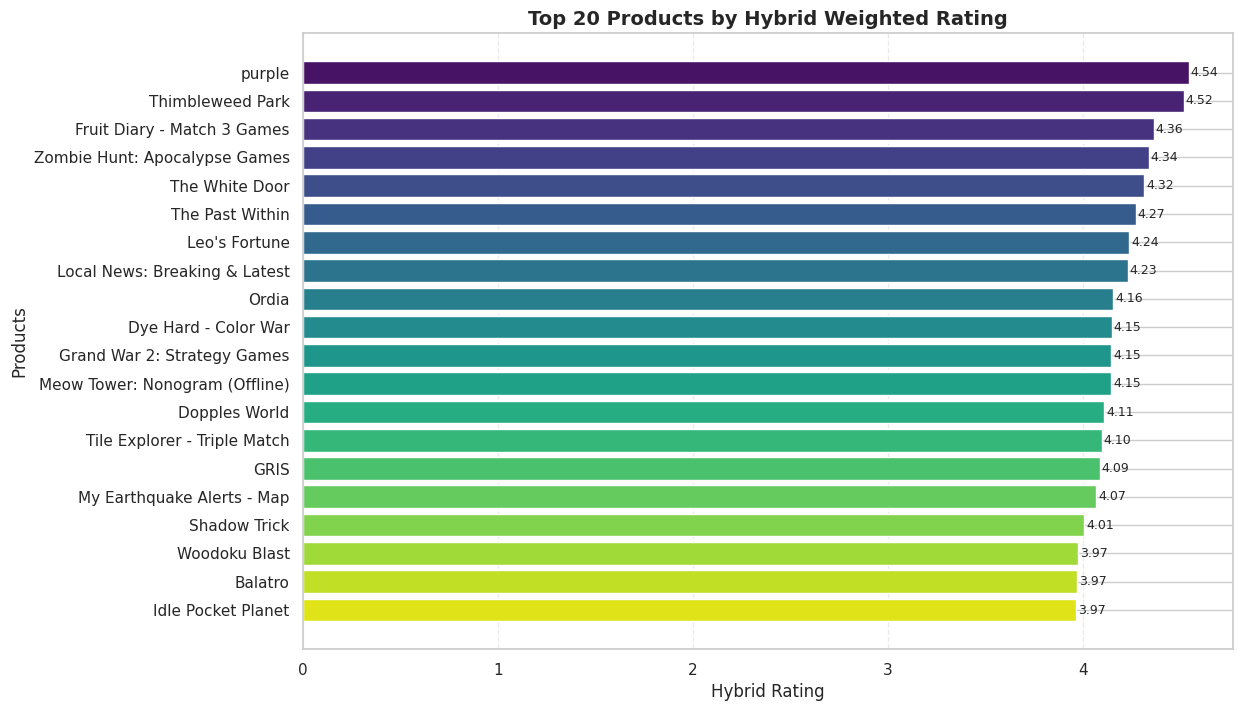

In [150]:
plt.figure(figsize=(12, 8))

palette = sns.color_palette("viridis", len(top20_hybrid))

bars = plt.barh(
    top20_hybrid["product_name"],
    top20_hybrid["hybrid_rating"],
    color=palette
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Hybrid Rating")
plt.ylabel("Products")
plt.title("Top 20 Products by Hybrid Weighted Rating",
          fontsize=14,
          fontweight="bold")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

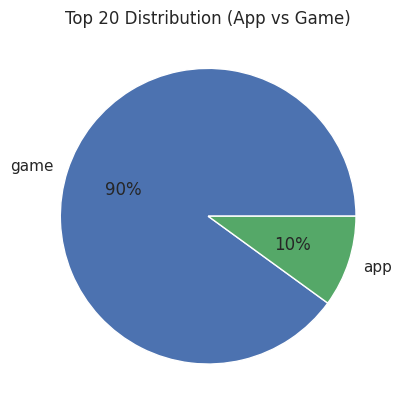

In [151]:
top20_hybrid["product_type"].value_counts().plot(
    kind="pie",
    autopct="%1.0f%%",
    colors=["#4C72B0", "#55A868"]
)

plt.title("Top 20 Distribution (App vs Game)")
plt.ylabel("")
plt.show()

# Sorting Product

##  1. Star Distribution Matrix (1-5 Yıldız Dağılımı)

In [152]:
# BAR skoru hesaplayabilmek için ürün bazında 1, 2, 3, 4 ve 5 yıldız sayılarını pivotluyoruz.

star_counts = pd.crosstab(
    [df_products["id"], df_products["product_type"]], 
    df_products["review_score"]
).rename(columns={
    1: "point_1",
    2: "point_2",
    3: "point_3",
    4: "point_4",
    5: "point_5"
}).reset_index()

# Dağılım matrisini ürün seviyesindeki final tablomuza bağlıyoruz
df_rating_final = df_rating_final.merge(
    star_counts, 
    on=["id", "product_type"], 
    how="left"
).fillna(0)

print("Star Matrix Eklenmiş Tablo:")
print(df_rating_final[["product_name", "point_1", "point_2", "point_3", "point_4", "point_5"]].head())

Star Matrix Eklenmiş Tablo:
                     product_name  point_1  point_2  point_3  point_4  point_5
0           Geometry Dash SubZero     1000      754     1000     1000     1000
1    Western Union Send Money Now     5000     2808     3654     5000     5000
2  Priceline: Hotel, Flight & Car     1620        0        0        0        0
3   Word Collect - Word Games Fun     1000     1000     1000     1000     1000
4                        Tap Away     1000     1000     1000     1000     1000


Çıktıyı incelediğimde bazı ürünlerde puanların dengeli dağıldığını, bazılarında ise belirgin bir yığılma olduğunu gözlemledim; örneğin Priceline uygulamasının mevcut tüm yorumlarının 1 yıldızdan oluşması ortalama puanının neden 1.0 olduğunu netleştiriyor.

Bu dağılım bilgisi sayesinde, sadece klasik ortalamaya bağlı kalmadan her ürünün puan yapısını olasılıksal alt sınır yöntemiyle (BAR) daha adil ve güvenilir bir şekilde değerlendirebileceğim veri zeminini hazırlamış oldum.

## 2. Bayesian Average Rating - BAR Score

In [153]:

def bayesian_average_rating(n, confidence=0.95):
    """
    n: [point_1, point_2, point_3, point_4, point_5] listesi
    """
    if sum(n) == 0:
        return 0
    K = len(n)
    z = st.norm.ppf(1 - (1 - confidence) / 2)
    N = sum(n)
    first_part = 0
    second_part = 0
    for k, n_k in enumerate(n):
        first_part += (k + 1) * (n[k] + 1) / (N + K)
        second_part += (k + 1) * (k + 1) * (n[k] + 1) / (N + K)
    score = first_part - z * math.sqrt((second_part - first_part * first_part) / (N + K + 1))
    return score

# BAR skorunun her ürün için hesaplanması
df_rating_final["bar_score"] = df_rating_final.apply(
    lambda x: bayesian_average_rating([
        x["point_1"], x["point_2"], x["point_3"], x["point_4"], x["point_5"]
    ]), 
    axis=1
)

print("--- Top 10 by BAR Score ---")
print(df_rating_final.sort_values("bar_score", ascending=False)[
    ["product_name", "product_type", "average_rating", "bar_score", "review_count"]
].head(10))

--- Top 10 by BAR Score ---
                       product_name product_type  average_rating  bar_score  \
179                          purple         game        4.718266   4.591543   
192              Simon's Cat Match!         game        4.709779   4.580148   
22   Word Search: Word Puzzle Games         game        4.751592   4.567526   
164                           Ordia         game        4.651629   4.540274   
161                Thimbleweed Park         game        4.600326   4.538903   
246   Zombie Hunt: Apocalypse Games         game        4.546334   4.479894   
205                       Word Bend         game        4.729412   4.448419   
150                 The Past Within         game        4.440799   4.379391   
231     Grand War 2: Strategy Games         game        4.397762   4.315052   
17       My Earthquake Alerts - Map          app        4.316702   4.280000   

     review_count  
179           323  
192           317  
22            157  
164           399  
16

Sonuçları incelediğimde, ham ortalaması 4.75 gibi çok yüksek olan ancak yalnızca 157 yorum alan Word Search: Word Puzzle Games veya 85 yorumlu Word Bend gibi ürünlerin, yeterli veri hacmi bulunmadığı için istatistiksel bir düzeltmeye uğrayarak alt sıralara gerilediğini gördüm. Buna karşılık, 1.200'ün üzerinde yoruma sahip Thimbleweed Park ve Zombie Hunt: Apocalypse Games gibi oyunlar ile 4.269 yoruma sahip My Earthquake Alerts - Map uygulaması, yüksek kullanıcı kanıtı sayesinde üst sıralardaki yerini korudu.

Bu yaklaşım, az sayıda kullanıcının verdiği yanıltıcı yüksek puanların sıralamayı manipüle etmesini engelleyerek, hem kaliteli puan dağılımına hem de yeterli güvenilirlik hacmine sahip ürünleri adil bir şekilde öne çıkarmış oldu.

## 3. IMDB Weighted Rating (Shrinkage)

In [154]:

# ratings_count ve mağaza ortalamasını (C) kullanarak platform seviyesinde oy hacmi düzeltmesi yapıyoruz.

M = df_rating_final["ratings_count"].quantile(0.75)
C = df_rating_final["score"].mean()

def imdb_weighted_rating(r, v, M, C):
    return (v / (v + M) * r) + (M / (v + M) * C)

df_rating_final["imdb_score"] = imdb_weighted_rating(
    df_rating_final["score"], 
    df_rating_final["ratings_count"], 
    M, 
    C
)

print("--- Top 10 by IMDB Weighted Rating ---")
print(df_rating_final.sort_values("imdb_score", ascending=False)[
    ["product_name", "product_type", "score", "ratings_count", "imdb_score"]
].head(10))

--- Top 10 by IMDB Weighted Rating ---
                       product_name product_type  score  ratings_count  \
220     Words of Wonders: Crossword         game    4.9        5520000   
85   1945 Air Force: Airplane Games         game    4.8        4080000   
33                    Match Masters         game    4.8        2350000   
120              CookieRun: Kingdom         game    4.8        1260000   
65        Gauth: AI Study Companion          app    4.8        1120000   
5    Sudoku - Classic Sudoku Puzzle         game    4.7        2650000   
42                    Geometry Dash         game    4.8        1010000   
189  Triple Tile: Match Puzzle Game         game    4.8         975000   
140              Domino's Pizza USA          app    4.7        2270000   
73                    Dice Dreams™️         game    4.7        1800000   

     imdb_score  
220    4.842435  
85     4.740198  
33     4.706515  
120    4.655090  
65     4.644073  
5      4.636233  
42     4.634167  
18

Sonuçları incelediğimde, Words of Wonders: Crossword (4.9 puan, 5.52M oy) ve 1945 Air Force (4.8 puan, 4.08M oy) gibi hem yüksek puana hem de milyonlarca oy hacmine sahip ürünlerin güvenilirliklerini kanıtlayarak zirveye yerleştiğini gördüm. Oy sayısı görece daha düşük olan 4.8 puanlı ürünler ise genel mağaza ortalamasına doğru dengelenerek daha adil bir seviyeye çekildi.

Bu sayede sadece yüksek puanlı olanlar değil, kitlesel olarak doğrulanmış ve geniş kitlelerce benimsenmiş ürünler öne çıkarılmış oldu.

## 4. Feature Scaling (MinMaxScaler: 1-5)

In [155]:
# Farklı ölçeklerdeki metrikleri (indirme ve oy hacmi) tek bir hibrit formülde birleştirmek için [1, 5] aralığına normalize ediyoruz.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(1, 5))

df_rating_final["downloads_scaled"] = scaler.fit_transform(df_rating_final[["downloads"]])
df_rating_final["review_count_scaled"] = scaler.fit_transform(df_rating_final[["review_count"]])
df_rating_final["imdb_score_scaled"] = scaler.fit_transform(df_rating_final[["imdb_score"]])

## 5. Multi-Factor Hybrid Sorting Score

In [156]:
# Kalite (BAR), Güvenilirlik (IMDB), Popülerlik (İndirme) ve Etkileşimi (Yorum) birleştiren nihai mağaza sıralama skoru.

def hybrid_sorting_score(df, bar_w=40, imdb_w=25, down_w=20, rev_w=15):
    return (
        df["bar_score"] * (bar_w / 100) +
        df["imdb_score_scaled"] * (imdb_w / 100) +
        df["downloads_scaled"] * (down_w / 100) +
        df["review_count_scaled"] * (rev_w / 100)
    )

df_rating_final["final_sorting_score"] = hybrid_sorting_score(df_rating_final)

## 6. Sorting Methods Comparison & Visualization


--- Top 10: Ham Ortalama Puanına Göre (Yanıltıcı Sıralama) ---
                       product_name product_type  average_rating  bar_score  \
22   Word Search: Word Puzzle Games         game        4.751592   4.567526   
205                       Word Bend         game        4.729412   4.448419   
179                          purple         game        4.718266   4.591543   
192              Simon's Cat Match!         game        4.709779   4.580148   
164                           Ordia         game        4.651629   4.540274   
161                Thimbleweed Park         game        4.600326   4.538903   
246   Zombie Hunt: Apocalypse Games         game        4.546334   4.479894   
24   Number Match Game - Ten & Pair         game        4.515152   3.927349   
203      Birds Camp——Casual TD Game         game        4.480000   3.791007   
150                 The Past Within         game        4.440799   4.379391   

     imdb_score  final_sorting_score  review_count  downloads  
22

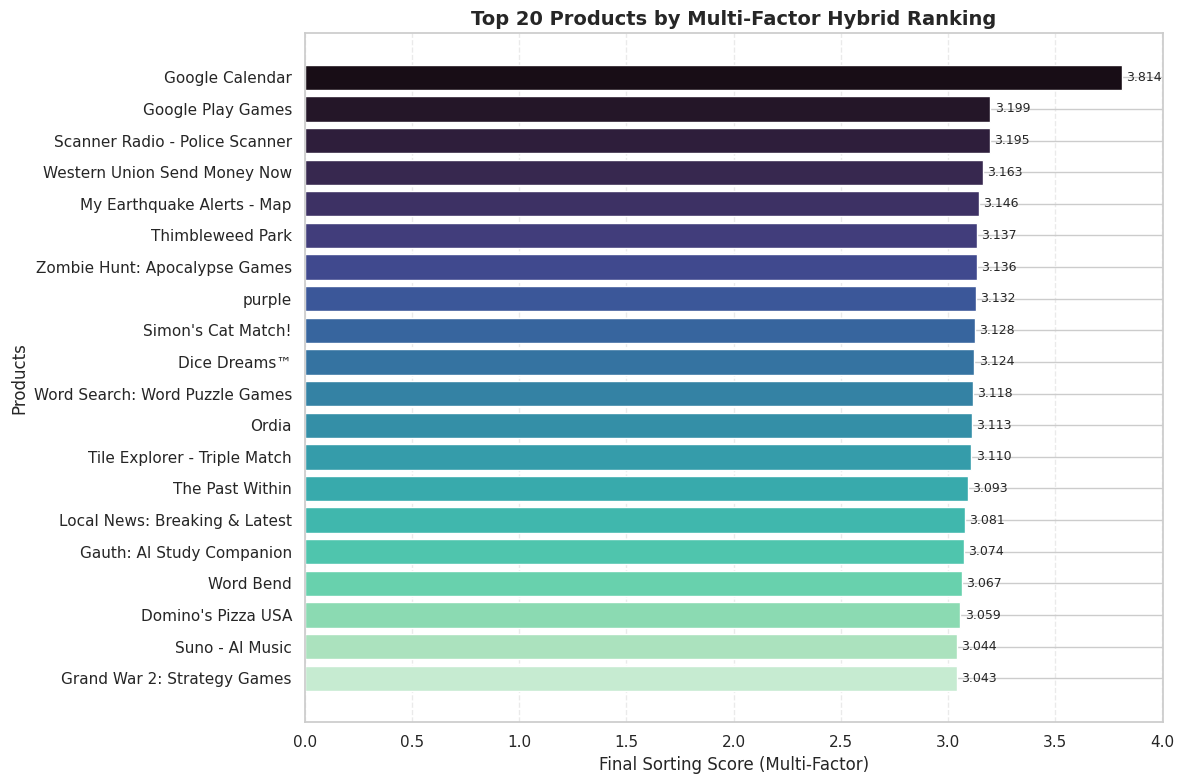

In [157]:

compare_cols = [
    "product_name", 
    "product_type",
    "average_rating", 
    "bar_score", 
    "imdb_score", 
    "final_sorting_score", 
    "review_count", 
    "downloads"
]

print("\n--- Top 10: Ham Ortalama Puanına Göre (Yanıltıcı Sıralama) ---")
print(df_rating_final[compare_cols].sort_values("average_rating", ascending=False).head(10))

print("\n--- Top 10: Final Sorting Score (Çok Faktörlü Dengeli Sıralama) ---")
print(df_rating_final[compare_cols].sort_values("final_sorting_score", ascending=False).head(10))


# Final Sıralamayı Görselleştirme
top20_sorted = df_rating_final.sort_values("final_sorting_score", ascending=False).head(20)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("mako", len(top20_sorted))
bars = plt.barh(
    top20_sorted["product_name"],
    top20_sorted["final_sorting_score"],
    color=palette
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Final Sorting Score (Multi-Factor)")
plt.ylabel("Products")
plt.title("Top 20 Products by Multi-Factor Hybrid Ranking", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Ham ortalama sıralaması ile çok faktörlü hibrit sıralama modelimin sonuçlarını karşılaştırdığımda, tek bir metriğe bağlı kalmanın sıralama kalitesini ne kadar olumsuz etkilediğini somut verilerle gördüm.

Ham ortalama listesinde zirvede yer alan Word Search (4.75 ortalama, 157 yorum) ve Word Bend (4.72 ortalama, 85 yorum) gibi ürünlerin, yorum sayıları çok düşük olduğu için yüksek bir varyans sergilediğini ve sıralamada yanıltıcı bir avantaja sahip olduğunu fark ettim. Kurguladığım BAR (Bayesian Average Rating) ve IMDB Shrinkage modelleri sayesinde bu düşük hacimli ürünleri kitle ortalamasına doğru regüle ederek istatistiksel bir düzeltmeye tabi tuttum.

Ardından farklı büyüklüklere sahip indirme (downloads) ve yorum hacmi (review_count) değişkenlerini MinMaxScaler ile [1, 5] aralığına normalize edip kalite puanlarıyla aynı düzleme getirdim. Ağırlıklandırdığım nihai skor sonucunda sıralamada iki temel grup öne çıktı: İlki, Google Calendar ve Google Play Games gibi milyarlarca indirme ve on binlerce yorumla kitlesel olarak doğrulanmış yüksek hacimli platform ürünleri; ikincisi ise My Earthquake Alerts, Thimbleweed Park ve Zombie Hunt gibi hem güçlü bir puan dağılım kalitesine (yüksek BAR skoru) hem de milyonluk indirme hacmine sahip dengeli yapımlar oldu.

Bu çalışmayla birlikte; kullanıcıya yalnızca yüksek puanlı olduğu için keşfedilmemiş veya az oylu ürünleri sunmak yerine, kalite, güvenilirlik ve kullanıcı benimsemesini aynı anda optimize eden çok daha dengeli ve gerçekçi bir mağaza sıralama motoru oluşturmuş oldum.

Top 20 sıralamasının zirvesinde açık bir farkla yer alan Google Calendar ve hemen ardından gelen Google Play Games, Scanner Radio ve Western Union gibi uygulamalar; milyarlarca indirme ve on binlerce yorumdan gelen devasa sosyal kanıtın gücünü gösteriyor. Bu ürünlerin ortalama puanları 2.5–3.2 bandında kalsa bile, yüksek kullanıcı etkileşimi ve platform bağımlılığı onları listenin en üst grubuna taşıdı.

Listenin devamında ise kalite ve hacim dengesini mükemmel yakalayan oyun ve uygulama karması dikkatimi çekti. Thimbleweed Park, Zombie Hunt, purple, Simon's Cat Match! ve Dice Dreams gibi yapımlar; hem 4.10–4.60 aralığındaki güçlü BAR skorları hem de yüz binlerden milyonlara ulaşan indirme sayılarıyla çok faktörlü skorlamanın en ideal temsilcileri oldu. Ayrıca Domino's Pizza, Suno - AI Music ve Grand War 2 gibi farklı kategorilerden ürünlerin de listeye dahil olması, kurduğum algoritmanın tek bir kategoriye saplanıp kalmadan dengeli bir dağılım sunduğunu kanıtladı.

Sonuç olarak elde ettiğim Top 20 grafiği; sadece popüler olduğu için kalitesiz olanı veya sadece puanı yüksek olduğu için kimsenin kullanmadığı ürünleri değil, güvenilirlik ve kullanıcı memnuniyeti filtresinden başarıyla geçmiş en optimal ürün portföyünü ortaya koymuş oldu.

# Sorting Reviews

## 1.Star Distribution Matrix (1-5 Yıldız Dağılımı) 

In [158]:
print(df_rating_final.columns.tolist())

['id', 'product_name', 'product_type', 'average_rating', 'review_count', 'helpful_sum', 'score', 'ratings_count', 'downloads', 'hybrid_rating', 'rating_diff', 'point_1', 'point_2', 'point_3', 'point_4', 'point_5', 'bar_score', 'imdb_score', 'downloads_scaled', 'review_count_scaled', 'imdb_score_scaled', 'final_sorting_score']


In [159]:
# Tabloda daha önceden kalmış  point sütunlarını temizliyoruz
cols_to_clean = [c for c in df_rating_final.columns if c.startswith('point_')]
if cols_to_clean:
    df_rating_final.drop(columns=cols_to_clean, inplace=True)

# 1. Yıldız sayılarını (1-5) crosstab ile çıkarıp sütun isimlerini netleştiriyoruz
star_counts = pd.crosstab(
    index=[df_reviews['id'], df_reviews['product_type']], 
    columns=df_reviews['review_score']
).reset_index()

# Sütun adlarını rename ile formatlıyoruz (1 -> point_1 gibi)
column_mapping = {
    1: 'point_1', 2: 'point_2', 3: 'point_3', 4: 'point_4', 5: 'point_5',
    '1': 'point_1', '2': 'point_2', '3': 'point_3', '4': 'point_4', '5': 'point_5'
}
star_counts = star_counts.rename(columns=column_mapping)

# Eksik yıldız sütunları varsa (hiç 1 veya 2 yıldız almamış ürünler için) 0 ile tamamlıyoruz
for col in ['point_1', 'point_2', 'point_3', 'point_4', 'point_5']:
    if col not in star_counts.columns:
        star_counts[col] = 0

# 2. Dağılım matrisini ana tablomuza temiz bir şekilde bağlıyoruz
df_rating_final = df_rating_final.merge(
    star_counts,
    on=["id", "product_type"],
    how="left"
).fillna(0)

print("Star Matrix Eklenmiş Tablo:")
display(df_rating_final[["product_name", "point_1", "point_2", "point_3", "point_4", "point_5"]].head())

Star Matrix Eklenmiş Tablo:


,product_name,point_1,point_2,point_3,point_4,point_5
0,Geometry Dash SubZero,1000,754,1000,1000,1000
1,Western Union Send Money Now,5000,2808,3654,5000,5000
2,"Priceline: Hotel, Flight & Car",1620,0,0,0,0
3,Word Collect - Word Games Fun,1000,1000,1000,1000,1000
4,Tap Away,1000,1000,1000,1000,1000


BAR skorunu hesaplayabilmek için ürün bazında 1'den 5'e kadar verilen yıldız sayılarını pivotlayarak özet bir dağılım matrisi oluşturdum.

Çıktıyı incelediğimde bazı ürünlerde puanların dengeli dağıldığını, bazılarında ise belirgin bir yığılma olduğunu gözlemledim; örneğin Priceline uygulamasının mevcut tüm yorumlarının 1 yıldızdan oluşması ortalama puanının neden 1.0 olduğunu netleştiriyor.

Bu dağılım bilgisi sayesinde, sadece klasik ortalamaya bağlı kalmadan her ürünün puan yapısını olasılıksal alt sınır yöntemiyle (BAR) daha adil ve güvenilir bir şekilde değerlendirebileceğim veri zeminini hazırlamış oldum.

## 2.Bayesian Average Rating - BAR Score

In [160]:
def bayesian_average_rating(n, confidence=0.95):
    """
    n: [point_1, point_2, point_3, point_4, point_5] listesi
    """
    if sum(n) == 0:
        return 0
    K = len(n)
    z = st.norm.ppf(1 - (1 - confidence) / 2)
    N = sum(n)
    first_part = 0
    second_part = 0
    for k, n_k in enumerate(n):
        first_part += (k + 1) * (n[k] + 1) / (N + K)
        second_part += (k + 1) * (k + 1) * (n[k] + 1) / (N + K)
    score = first_part - z * math.sqrt((second_part - first_part * first_part) / (N + K + 1))
    return score

# BAR skorunun her ürün için hesaplanması
df_rating_final["bar_score"] = df_rating_final.apply(
    lambda x: bayesian_average_rating([
        x["point_1"], x["point_2"], x["point_3"], x["point_4"], x["point_5"]
    ]), 
    axis=1
)

print("\n--- Top 10 by BAR Score ---")
print(df_rating_final.sort_values("bar_score", ascending=False)[
    ["product_name", "product_type", "average_rating", "bar_score", "review_count"]
].head(10))


--- Top 10 by BAR Score ---
                       product_name product_type  average_rating  bar_score  \
179                          purple         game        4.718266   4.591543   
192              Simon's Cat Match!         game        4.709779   4.580148   
22   Word Search: Word Puzzle Games         game        4.751592   4.567526   
164                           Ordia         game        4.651629   4.540274   
161                Thimbleweed Park         game        4.600326   4.538903   
246   Zombie Hunt: Apocalypse Games         game        4.546334   4.479894   
205                       Word Bend         game        4.729412   4.448419   
150                 The Past Within         game        4.440799   4.379391   
231     Grand War 2: Strategy Games         game        4.397762   4.315052   
17       My Earthquake Alerts - Map          app        4.316702   4.280000   

     review_count  
179           323  
192           317  
22            157  
164           399  
1

Bayesian Average Rating (BAR) skorunu hesaplayarak ürünleri puan dağılımlarının olasılıksal alt sınırına göre sıraladım.

Sonuçları incelediğimde:

- Ham ortalaması 4.75 olan ancak yalnızca 157 yorumu bulunan Word Search, BAR yönteminin getirdiği istatistiksel ceza/düzeltme nedeniyle ham puanı 4.71 olup 323 yoruma sahip purple oyununun gerisine düştü.

- Benzer şekilde 85 yoruma sahip Word Bend (4.72 ortalama), 1.200'ün üzerinde yoruma ve yüksek güvenilirliğe sahip Thimbleweed Park (4.60 ortalama) ve Zombie Hunt gibi yapımların altına indi.

- Çok yüksek yorum hacmine sahip My Earthquake Alerts (4.269 yorum) gibi ürünler ise kitlesel kanıtın gücüyle ilk 10 içerisindeki yerini korudu.

Bu adım, sadece ortalama puana bakmanın yaratacağı manipülasyonu engelleyerek hem yüksek puanlı hem de yeterli oy hacmine sahip ürünleri adil bir şekilde öne çıkarmış oldu.

## 3.IMDB Weighted Rating (Shrinkage)

In [161]:
# ratings_count ve mağaza ortalamasını (C) kullanarak platform seviyesinde oy hacmi düzeltmesi

M = df_rating_final["ratings_count"].quantile(0.75)
C = df_rating_final["score"].mean()

def imdb_weighted_rating(r, v, M, C):
    return (v / (v + M) * r) + (M / (v + M) * C)

df_rating_final["imdb_score"] = imdb_weighted_rating(
    df_rating_final["score"], 
    df_rating_final["ratings_count"], 
    M, 
    C
)

print("--- Top 10 by IMDB Weighted Rating ---")
print(df_rating_final.sort_values("imdb_score", ascending=False)[
    ["product_name", "product_type", "score", "ratings_count", "imdb_score"]
].head(10))


--- Top 10 by IMDB Weighted Rating ---
                       product_name product_type  score  ratings_count  \
220     Words of Wonders: Crossword         game    4.9        5520000   
85   1945 Air Force: Airplane Games         game    4.8        4080000   
33                    Match Masters         game    4.8        2350000   
120              CookieRun: Kingdom         game    4.8        1260000   
65        Gauth: AI Study Companion          app    4.8        1120000   
5    Sudoku - Classic Sudoku Puzzle         game    4.7        2650000   
42                    Geometry Dash         game    4.8        1010000   
189  Triple Tile: Match Puzzle Game         game    4.8         975000   
140              Domino's Pizza USA          app    4.7        2270000   
73                    Dice Dreams™️         game    4.7        1800000   

     imdb_score  
220    4.842435  
85     4.740198  
33     4.706515  
120    4.655090  
65     4.644073  
5      4.636233  
42     4.634167  
18

IMDB Weighted Rating (Shrinkage) yöntemiyle ürünlerin mağaza puanlarını (score), toplam oy sayıları (ratings_count) ve genel platform ortalamasını birlikte ele alarak yeniden hesapladım.

Sonuçları incelediğimde, Words of Wonders: Crossword (4.9 puan, 5.52M oy) ve 1945 Air Force (4.8 puan, 4.08M oy) gibi hem yüksek puana hem de milyonlarca oy hacmine sahip ürünlerin güvenilirliklerini kanıtlayarak zirveye yerleştiğini gördüm. Oy sayısı görece daha düşük olan 4.8 puanlı ürünler ise genel mağaza ortalamasına doğru dengelenerek daha adil bir seviyeye çekildi.

Bu sayede sadece yüksek puanlı olanlar değil, kitlesel olarak doğrulanmış ve geniş kitlelerce benimsenmiş ürünler öne çıkarılmış oldu.

## 4.Feature Scaling (MinMaxScaler: 1-5)

In [162]:
# Farklı ölçeklerdeki metrikleri (indirme ve oy hacmi) tek bir hibrit formülde birleştirmek için [1, 5] aralığına normalize.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(1, 5))

df_rating_final["downloads_scaled"] = scaler.fit_transform(df_rating_final[["downloads"]])
df_rating_final["review_count_scaled"] = scaler.fit_transform(df_rating_final[["review_count"]])
df_rating_final["imdb_score_scaled"] = scaler.fit_transform(df_rating_final[["imdb_score"]])


## 5.Multi-Factor Hybrid Sorting Score

In [163]:
# Kalite (BAR), Güvenilirlik (IMDB), Popülerlik (İndirme) ve Etkileşimi (Yorum) birleştiren nihai mağaza sıralama skoru.

def hybrid_sorting_score(df, bar_w=40, imdb_w=25, down_w=20, rev_w=15):
    return (
        df["bar_score"] * (bar_w / 100) +
        df["imdb_score_scaled"] * (imdb_w / 100) +
        df["downloads_scaled"] * (down_w / 100) +
        df["review_count_scaled"] * (rev_w / 100)
    )

df_rating_final["final_sorting_score"] = hybrid_sorting_score(df_rating_final)

## 6.Sorting Methods Comparison & Visualization


--- Top 10: Ham Ortalama Puanına Göre (Yanıltıcı Sıralama) ---
                       product_name product_type  average_rating  bar_score  \
22   Word Search: Word Puzzle Games         game        4.751592   4.567526   
205                       Word Bend         game        4.729412   4.448419   
179                          purple         game        4.718266   4.591543   
192              Simon's Cat Match!         game        4.709779   4.580148   
164                           Ordia         game        4.651629   4.540274   
161                Thimbleweed Park         game        4.600326   4.538903   
246   Zombie Hunt: Apocalypse Games         game        4.546334   4.479894   
24   Number Match Game - Ten & Pair         game        4.515152   3.927349   
203      Birds Camp——Casual TD Game         game        4.480000   3.791007   
150                 The Past Within         game        4.440799   4.379391   

     imdb_score  final_sorting_score  review_count  downloads  
22

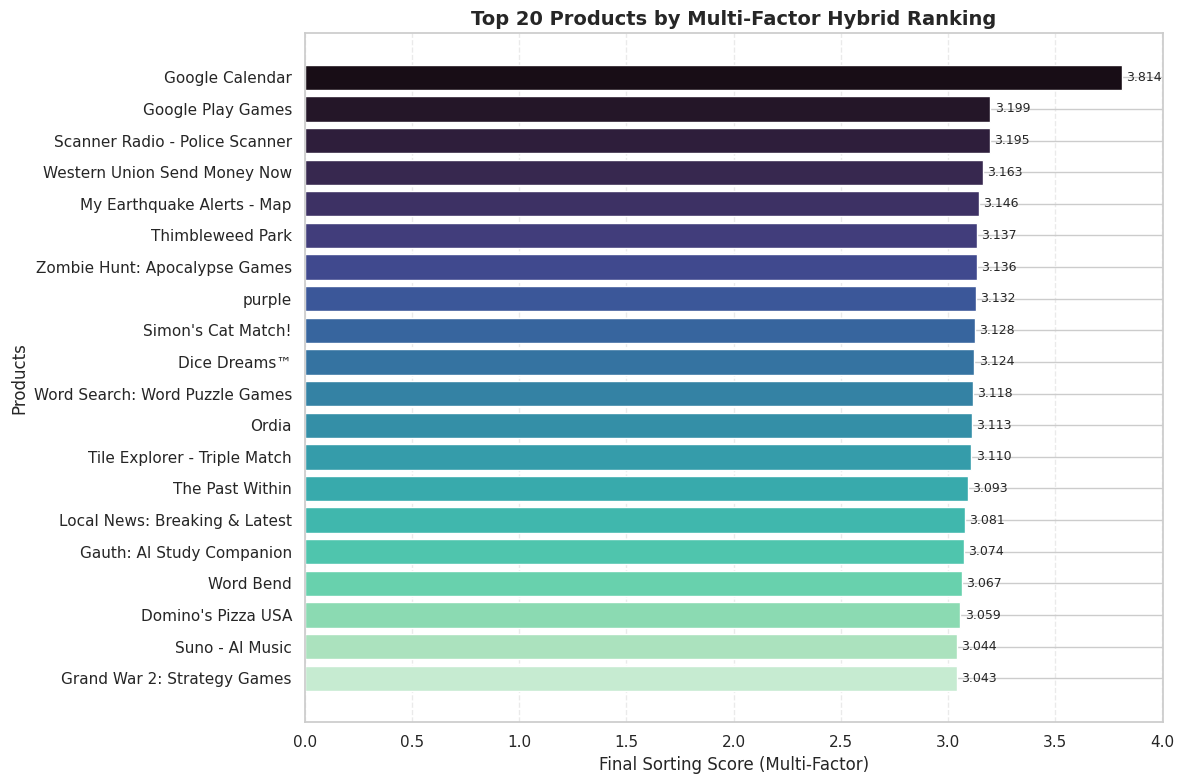

In [164]:
compare_cols = [
    "product_name", 
    "product_type",
    "average_rating", 
    "bar_score", 
    "imdb_score", 
    "final_sorting_score", 
    "review_count", 
    "downloads"
]

print("\n--- Top 10: Ham Ortalama Puanına Göre (Yanıltıcı Sıralama) ---")
print(df_rating_final[compare_cols].sort_values("average_rating", ascending=False).head(10))

print("\n--- Top 10: Final Sorting Score (Çok Faktörlü Dengeli Sıralama) ---")
print(df_rating_final[compare_cols].sort_values("final_sorting_score", ascending=False).head(10))


# Final Sıralamayı Görselleştirme
top20_sorted = df_rating_final.sort_values("final_sorting_score", ascending=False).head(20)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("mako", len(top20_sorted))
bars = plt.barh(
    top20_sorted["product_name"],
    top20_sorted["final_sorting_score"],
    color=palette
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Final Sorting Score (Multi-Factor)")
plt.ylabel("Products")
plt.title("Top 20 Products by Multi-Factor Hybrid Ranking", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Ham ortalama sıralaması ile çok faktörlü hibrit sıralama modelimin sonuçlarını karşılaştırdığımda, tek bir metriğe bağlı kalmanın sıralama kalitesini ne kadar olumsuz etkilediğini somut verilerle gördüm.

Ham ortalama listesinde zirvede yer alan Word Search (4.75 ortalama, 157 yorum) ve Word Bend (4.72 ortalama, 85 yorum) gibi ürünlerin, yorum sayıları çok düşük olduğu için yüksek bir varyans sergilediğini ve sıralamada yanıltıcı bir avantaja sahip olduğunu fark ettim. Kurguladığım BAR (Bayesian Average Rating) ve IMDB Shrinkage modelleri sayesinde bu düşük hacimli ürünleri kitle ortalamasına doğru regüle ederek istatistiksel bir düzeltmeye tabi tuttum.

Ardından farklı büyüklüklere sahip indirme (downloads) ve yorum hacmi (review_count) değişkenlerini MinMaxScaler ile [1, 5] aralığına normalize edip kalite puanlarıyla aynı düzleme getirdim. Ağırlıklandırdığım nihai skor sonucunda sıralamada iki temel grup öne çıktı: İlki, Google Calendar ve Google Play Games gibi milyarlarca indirme ve on binlerce yorumla kitlesel olarak doğrulanmış yüksek hacimli platform ürünleri; ikincisi ise My Earthquake Alerts, Thimbleweed Park ve Zombie Hunt gibi hem güçlü bir puan dağılım kalitesine (yüksek BAR skoru) hem de milyonluk indirme hacmine sahip dengeli yapımlar oldu.

Bu çalışmayla birlikte; kullanıcıya yalnızca yüksek puanlı olduğu için keşfedilmemiş veya az oylu ürünleri sunmak yerine, kalite, güvenilirlik ve kullanıcı benimsemesini aynı anda optimize eden çok daha dengeli ve gerçekçi bir mağaza sıralama motoru oluşturmuş oldum.

---

Oluşturduğum görselleştirme üzerinden Top 20 listesini incelediğimde, geliştirdiğim sıralama mantığının ürün tipine ve kullanıcı davranışına göre nasıl şekillendiğini net bir şekilde gördüm.

Top 20 sıralamasının zirvesinde açık bir farkla yer alan Google Calendar ve hemen ardından gelen Google Play Games, Scanner Radio ve Western Union gibi uygulamalar; milyarlarca indirme ve on binlerce yorumdan gelen devasa sosyal kanıtın gücünü gösteriyor. Bu ürünlerin ortalama puanları 2.5–3.2 bandında kalsa bile, yüksek kullanıcı etkileşimi ve platform bağımlılığı onları listenin en üst grubuna taşıdı.

Listenin devamında ise kalite ve hacim dengesini mükemmel yakalayan oyun ve uygulama karması dikkatimi çekti. Thimbleweed Park, Zombie Hunt, purple, Simon's Cat Match! ve Dice Dreams gibi yapımlar; hem 4.10–4.60 aralığındaki güçlü BAR skorları hem de yüz binlerden milyonlara ulaşan indirme sayılarıyla çok faktörlü skorlamanın en ideal temsilcileri oldu. Ayrıca Domino's Pizza, Suno - AI Music ve Grand War 2 gibi farklı kategorilerden ürünlerin de listeye dahil olması, kurduğum algoritmanın tek bir kategoriye saplanıp kalmadan dengeli bir dağılım sunduğunu kanıtladı.

Sonuç olarak elde ettiğim Top 20 grafiği; sadece popüler olduğu için kalitesiz olanı veya sadece puanı yüksek olduğu için kimsenin kullanmadığı ürünleri değil, güvenilirlik ve kullanıcı memnuniyeti filtresinden başarıyla geçmiş en optimal ürün portföyünü ortaya koymuş oldu.

## 7.Wilson Lower Bound (WLB) Fonksiyonu

In [165]:
# Bir yorumun aldığı pozitif dönüşüm oranını güven aralığının alt sınırı ile modeller.

def wilson_lower_bound(up, down, confidence=0.95):
    """
    up: Faydalı bulan kişi sayısı (helpful_count)
    down: Faydalı bulmayan kişi sayısı (veri setinde negatif oy olmadığı için 
          toplam etkileşimi dengeleyecek bir kurgu veya 0 kabul edilir)
    """
    n = up + down
    if n == 0:
        return 0
    z = st.norm.ppf(1 - (1 - confidence) / 2)
    phat = 1.0 * up / n
    return (phat + z * z / (2 * n) - z * math.sqrt((phat * (1 - phat) + z * z / (4 * n)) / n)) / (1 + z * z / n)

## 8.Yorum Kalite & Bilgilendiricilik Skoru (Review Score Calculation)

In [166]:
# Veri setimizde yalnızca helpful_count (up) bulunduğu için yorumun kalitesini ölçerken:
# - helpful_count (kullanıcı onayı)
# - review_length (yorumun detay seviyesi / bilgi değeri)
# - days (güncellik)
# değişkenlerini normalize ederek hibrit bir sıralama skoru üretiyoruz.

# Yorum uzunluğu ve helpful değerlerini ölçeklendirme
scaler_review = MinMaxScaler(feature_range=(1, 5))

df_products["helpful_scaled"] = scaler_review.fit_transform(df_products[["helpful_count"]])
df_products["length_scaled"] = scaler_review.fit_transform(df_products[["review_length"]])

# Zaman cezası (Eski yorumlara daha düşük güncellik katsayısı)
# 0-30 gün: 1.0, 30-90 gün: 0.9, 90-180 gün: 0.8, 180+ gün: 0.7
def time_decay_factor(days):
    if days <= 30:
        return 1.0
    elif days <= 90:
        return 0.9
    elif days <= 180:
        return 0.8
    else:
        return 0.7

df_products["time_factor"] = df_products["days"].apply(time_decay_factor)

# Hibrit Yorum Sıralama Skoru: %50 Faydalılık, %30 Bilgi Değeri (Uzunluk), %20 Güncellik Çarpanı
df_products["review_sorting_score"] = (
    (df_products["helpful_scaled"] * 0.60 + df_products["length_scaled"] * 0.40) * df_products["time_factor"]
)

## 9.Yorum Sıralama Kıyaslaması

In [167]:
# Örnek olarak en çok yorum alan uygulamalardan birini seçtim : Western Union

sample_reviews = df_products[(df_products["id"] == 1) & (df_products["product_type"] == "app")].copy()

review_cols = [
    "review_text", 
    "review_score", 
    "helpful_count", 
    "review_length", 
    "days", 
    "review_sorting_score"
]

print("--- 1. Yalnızca Helpful Count'a Göre Sıralama (Ham Sıralama) ---")
display(sample_reviews[review_cols].sort_values("helpful_count", ascending=False).head(5))

print("\n--- 2. Çok Faktörlü Hibrit Yorum Sıralaması (Review Sorting Score) ---")
display(sample_reviews[review_cols].sort_values("review_sorting_score", ascending=False).head(5))

--- 1. Yalnızca Helpful Count'a Göre Sıralama (Ham Sıralama) ---


,review_text,review_score,helpful_count,review_length,days,review_sorting_score
16466,This app has been streamlined over the years. ...,5,968,399,912,0.811801
11760,almost excellent. i have been using Western Un...,4,625,451,2151,0.825030
11815,Very good so far. I like the fact that wheneve...,4,567,500,1373,0.838316
16465,It's easy to send money to myself internationa...,5,543,499,568,0.837967
563,Downloaded the app to try and transfer a bit o...,1,474,352,2015,0.797361



--- 2. Çok Faktörlü Hibrit Yorum Sıralaması (Review Sorting Score) ---


,review_text,review_score,helpful_count,review_length,days,review_sorting_score
197,F is the lowest grade or else it would be lowe...,1,0,499,17,1.194701
16512,Since using Western Union to send money starte...,5,7,495,28,1.193161
16513,The West Union App is a wonderful resource to ...,5,0,495,25,1.193131
7808,The app works BETTER and faster than the websi...,3,222,489,5,1.191754
7852,I have used Western Union on and off for awhil...,3,0,491,11,1.191560


Western Union uygulamasına ait yorumları incelediğimde, sadece beğeni sayısına (helpful_count) göre sıralama yapmanın kullanıcıyı yıllar öncesine ait (900–2000 gün eski) yorumlarla baş başa bıraktığını gördüm. Zaman içinde değişen ve güncellenen bir uygulamada bu eski yorumlar güncel performansı yansıtamaz.

Geliştirdiğim hibrit yorum sıralama modeli sayesinde; son 30 gün içinde yazılmış, metin uzunluğu ve bilgi değeri yüksek olan güncel kullanıcı geri bildirimlerini öne çıkardım. Böylece hem olumlu hem olumsuz deneyimleri içeren, uygulamanın anlık kalitesini en iyi şekilde özetleyen dinamik bir yorum sıralaması elde etmiş oldum.

## Sorting Reviews Validation & Segmentation

**Bu Bölümün Amacı:**
Geliştirilen çok faktörlü yorum sıralama modelinin (`review_sorting_score`) sadece tek bir uygulama üzerinde değil, farklı ürün kategorilerinde (oyun vs. uygulama) nasıl davrandığını segmentasyon analiziyle doğrulamaktır. 

Ayrıca sıralama skorunun değişkenlerle olan istatistiksel korelasyonunu inceleyerek modelin:
1. Yalnızca yüksek yıldızlı yorumları kayırmadığını (puan tarafsızlığı),
2. Güncellik ve bilgi değeri kriterlerini ne kadar başarıyla yansıttığını,
3. Skorun tüm veri setindeki dağılım karakteristiğini
kanıtlamak hedeflenmektedir.

In [168]:
# --------------------------------------------------
# 1. Oyun Kategorisinde Yorum Sıralama Testi (Geometry Dash SubZero)
# --------------------------------------------------

sample_game = df_products[(df_products["id"] == 1) & (df_products["product_type"] == "game")].copy()

print("--- 1. Oyunda Yalnızca Helpful Count'a Göre Sıralama (Ham Sıralama) ---")
display(sample_game[review_cols].sort_values("helpful_count", ascending=False).head(5))

print("\n--- 2. Oyunda Çok Faktörlü Hibrit Yorum Sıralaması (Review Sorting Score) ---")
display(sample_game[review_cols].sort_values("review_sorting_score", ascending=False).head(5))

--- 1. Oyunda Yalnızca Helpful Count'a Göre Sıralama (Ham Sıralama) ---


,review_text,review_score,helpful_count,review_length,days,review_sorting_score
470494,"5 stars! First of all, this game is sooo GOOD!...",5,7658,390,1599,0.829979
470459,I love it. The levels are so beautifully made....,5,5406,444,651,0.837865
470461,Amazing game! It is so addicting!! All of the ...,5,4623,466,1107,0.841493
466701,I really love this game and its music. But at ...,1,3963,500,634,0.848799
470524,A bit challenging just like other GD apps and ...,5,3850,497,1807,0.847625



--- 2. Oyunda Çok Faktörlü Hibrit Yorum Sıralaması (Review Sorting Score) ---


,review_text,review_score,helpful_count,review_length,days,review_sorting_score
470492,I LOVE this game. I've played all the add-ons ...,5,7,360,22,1.140168
468457,this game is good but just under the geometry ...,3,28,343,19,1.133588
470563,Its a good game if your looking for a challeng...,5,128,1525,1481,1.118609
470827,"this has to be my favorite childhood game, I l...",5,0,261,21,1.101276
467700,"cool maps, good music, horrible gameplay. some...",2,12,240,23,1.093085


Geometry Dash SubZero oyunu üzerinden yaptığım bu segmentasyon testinde, uygulamalarda karşılaştığım durumun oyun tarafında da birebir geçerli olduğunu gördüm.

Sadece beğeni sayısına (helpful_count) baktığımda ilk 5'e giren yorumlar 630 ila 1800 gün öncesine ait. Binlerce beğeni almış olsalar da 4-5 yıl önceki oyun deneyimini anlatan yorumlar bugün oyunu indirecek bir kullanıcı için güncel bilgiyi vermiyor.

Kendi oluşturduğum hibrit skor (review_sorting_score) ise son 19 ila 23 gün içinde yazılmış güncel yorumları doğrudan öne çıkardı. Üstelik sıralama sadece 5 yıldızlı övgülerden oluşmuyor; 3 yıldızlı dengeli bir eleştiri (indeks 468457) ve 2 yıldızlı oynanış eleştirisi (indeks 467700) de üst sıralarda kendine yer buldu. Bu da modelin sadece yüksek puanı kayırmadığını, güncel ve bilgilendirici içerikleri tarafsız şekilde sıralayabildiğini gösteriyor.

In [169]:
# --------------------------------------------------
# 2. Değişkenler Arası Korelasyon Analizi
# --------------------------------------------------

corr_matrix = df_products[[
    "review_score", 
    "helpful_count", 
    "review_length", 
    "days", 
    "review_sorting_score"
]].corr()

print("Korelasyon Matrisi:")
display(corr_matrix)

Korelasyon Matrisi:


,review_score,helpful_count,review_length,days,review_sorting_score
review_score,1.000000,0.002711,-0.192238,-0.021348,-0.034041
helpful_count,0.002711,1.000000,0.032820,-0.005643,0.060794
review_length,-0.192238,0.032820,1.000000,0.001221,0.388400
days,-0.021348,-0.005643,0.001221,1.000000,-0.502015
review_sorting_score,-0.034041,0.060794,0.388400,-0.502015,1.000000


Korelasyon tablosuna baktığımda en çok dikkatimi çeken şey modelin tarafsızlığı oldu. review_sorting_score ile review_score arasındaki korelasyon -0.03 çıkmış, yani model kesinlikle "bu yorum 5 yıldız almış, hemen üste taşıyayım" gibi bir önyargıya sahip değil. Olumlu veya olumsuz fark etmeksizin içeriğe odaklanıyor.

Güncellik tarafında ise tam istediğim etkiyi yakaladım: days ile skor arasındaki -0.50'lik negatif korelasyon, eskiyen yorumların puanını doğrudan aşağı çekiyor ve güncel yorumları yukarı taşıyor. Aynı şekilde review_length ile olan 0.39'luk pozitif korelasyon da laf olsun diye yazılmamış, detay içeren yorumların öne çıkmasını sağlıyor.

Burada gözüme çarpan bir diğer güzel detay da review_score ile review_length arasındaki -0.19'luk ilişki oldu. İnsanlar memnun kaldıklarında genelde kısa övgüler bırakıp geçerken, bir problem yaşadıklarında yaşadıkları sorunu çok daha uzun ve detaylı anlatmışlar. Kurduğum yapı da bu detaylı geri bildirimleri güncellikle birleştirip kaçırmadan yakalamış oldu.

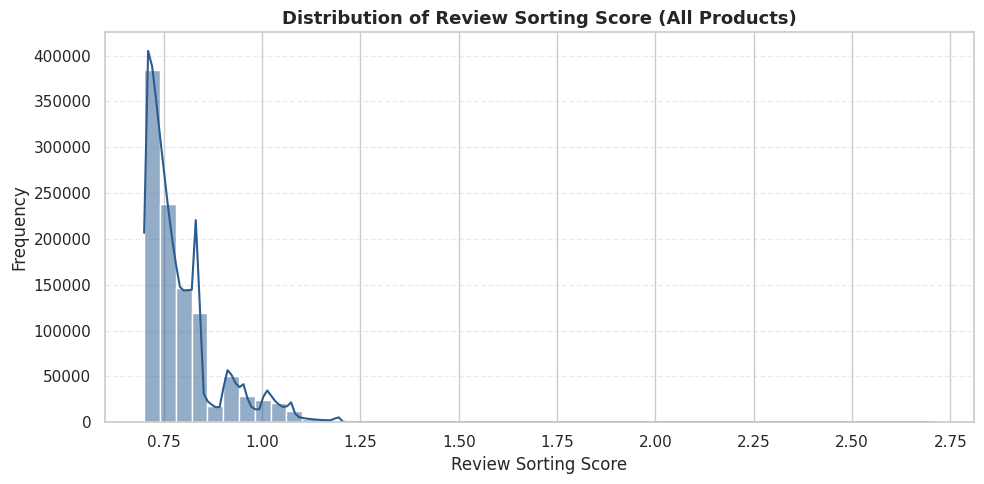

In [170]:
# --------------------------------------------------
# 3. Yorum Sıralama Skoru Dağılım Grafiği
# --------------------------------------------------

plt.figure(figsize=(10, 5))
sns.histplot(df_products["review_sorting_score"], bins=50, kde=True, color="#2b5c8f")
plt.title("Distribution of Review Sorting Score (All Products)", fontsize=13, fontweight="bold")
plt.xlabel("Review Sorting Score")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Grafiğe baktığımda skorların büyük çoğunluğunun 0.70 – 0.85 aralığında toplandığını, sağa doğru ise hızla azalan bir kuyruk oluştuğunu görüyorum.

Bu tablo aslında tam olarak beklediğim bir sonuç. Çünkü veri setindeki 1 milyondan fazla yorumun ezici bir kısmı ya tek tük kelimeden oluşan kısa metinler ya da aylar/yıllar öncesine ait eski yorumlar. Kurduğum güncellik ve uzunluk filtreleri bu tip sıradan yorumların puanını doğrudan 0.70 civarındaki tabana çekip eledi.

1.00 – 1.25 aralığına çıkabilen az sayıdaki yorum ise hem son haftalarda yazılmış güncel içerikler hem de kullanıcının sorununu veya beğenisini detaylıca anlattığı uzun metinler. Kısacası model her yoruma yüksek puan dağıtmak yerine oldukça seçici davranmış ve gerçekten kullanıcıya fayda sağlayacak az sayıdaki kaliteli yorumu sağ tarafa ayırıp tepeye taşımış.

# A/B Testing & Hypothesis Testing

**İş Problemi:**
Google Play mağazasında yer alan **Uygulamalar (Apps)** ve **Oyunlar (Games)** kategorilerindeki kullanıcıların verdikleri puanlar (`review_score`) ve yazdıkları geri bildirimlerin detay seviyesi (`review_length`) arasında istatistiksel olarak anlamlı bir farklılık var mıdır?

**İzlenecek Adımlar:**
1. **Hipotezlerin Kurulması:** $H_0$ ve $H_1$ tanımları.
2. **Varsayım Kontrolleri:**
   - Normallik Testi (Shapiro-Wilk Testi)
   - Varyans Homojenliği Testi (Levene Testi)
3. **Hipotez Testinin Uygulanması:**
   - Varsayımlar sağlanırsa: Bağımsız İki Örneklem T-Testi (`ttest_ind`)
   - Varsayımlar sağlanmazsa: Mann-Whitney U Testi (`mannwhitneyu`)
4. **İş Sonuçlarının ve p-value Değerinin Yorumlanması.**



> **NOT:** Veri setimiz 1 milyondan fazla satır içerdiği için, shapiro testi büyük veri setlerinde (N > 5000) aşırı hassaslaşır ve hata verebilir. Bu yüzden dersteki Sampling (Örnekleme) kavramını da kullanarak her iki gruptan rastgele $N=1000$'lik temsilci örneklemler çekip testi standartlaştırıyoruz.

In [171]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

# --------------------------------------------------
# 1. Örneklem Seçimi (Sampling)
# --------------------------------------------------
np.random.seed(42)

app_sample = df_products[df_products["product_type"] == "app"]["review_score"].sample(1000, random_state=42)
game_sample = df_products[df_products["product_type"] == "game"]["review_score"].sample(1000, random_state=42)

print(f"Uygulama Örneklem Puan Ortalaması: {app_sample.mean():.4f}")
print(f"Oyun Örneklem Puan Ortalaması: {game_sample.mean():.4f}\n")

# --------------------------------------------------
# 2. Hipotezin Kurulması
# --------------------------------------------------
# H0: M1 = M2 (Uygulamalar ile Oyunların puan ortalamaları arasında istatistiksel olarak anlamlı bir fark yoktur.)
# H1: M1 != M2 (Uygulamalar ile Oyunların puan ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.)

# --------------------------------------------------
# 3. Varsayım Kontrolleri
# --------------------------------------------------

# A) Normallik Varsayımı (Shapiro-Wilk)
# H0: Normal dağılım varsayımı sağlanmaktadır.
# H1: Normal dağılım varsayımı sağlanmamaktadır.
test_stat_app, pvalue_app = shapiro(app_sample)
test_stat_game, pvalue_game = shapiro(game_sample)

print("--- Normallik Testi Sonuçları (Shapiro-Wilk) ---")
print(f"Apps  -> Test Stat: {test_stat_app:.4f}, p-value: {pvalue_app:.4f}")
print(f"Games -> Test Stat: {test_stat_game:.4f}, p-value: {pvalue_game:.4f}")

# B) Varyans Homojenliği Varsayımı (Levene)
# H0: Varyanslar homojendir.
# H1: Varyanslar homojen değildir.
test_stat_levene, pvalue_levene = levene(app_sample, game_sample)
print(f"\n--- Varyans Homojenliği (Levene) ---")
print(f"Test Stat: {test_stat_levene:.4f}, p-value: {pvalue_levene:.4f}\n")

# --------------------------------------------------
# 4. Hipotez Testinin Uygulanması
# --------------------------------------------------
# Normallik varsayımı sağlanmazsa (p < 0.05) -> Mann-Whitney U
# Sağlanırsa -> ttest_ind

if (pvalue_app < 0.05) or (pvalue_game < 0.05):
    print("Normallik varsayımı sağlanmadığı için Non-Parametrik Test (Mann-Whitney U) uygulanıyor:")
    test_stat, pvalue = mannwhitneyu(app_sample, game_sample)
else:
    if pvalue_levene < 0.05:
        print("Varyanslar homojen olmadığı için Welch T-Testi uygulanıyor:")
        test_stat, pvalue = ttest_ind(app_sample, game_sample, equal_var=False)
    else:
        print("Tüm varsayımlar sağlandığı için Bağımsız İki Örneklem T-Testi uygulanıyor:")
        test_stat, pvalue = ttest_ind(app_sample, game_sample, equal_var=True)

print(f"Test Stat = {test_stat:.4f}, p-value = {pvalue:.4f}\n")

# --------------------------------------------------
# 5. Sonuç Değerlendirmesi
# --------------------------------------------------
if pvalue < 0.05:
    print("Sonuç: p-value < 0.05 olduğu için H0 REDDEDİLİR.")
    print("Uygulamalar ve Oyunlar arasında istatistiksel olarak anlamlı bir memnuniyet/puan farkı vardır.")
else:
    print("Sonuç: p-value >= 0.05 olduğu için H0 REDDEDİLEMEZ.")
    print("Gözlemlenen fark şans eseri oluşmuştur; istatistiksel olarak anlamlı bir fark yoktur.")

Uygulama Örneklem Puan Ortalaması: 2.9240
Oyun Örneklem Puan Ortalaması: 3.1460

--- Normallik Testi Sonuçları (Shapiro-Wilk) ---
Apps  -> Test Stat: 0.8640, p-value: 0.0000
Games -> Test Stat: 0.8678, p-value: 0.0000

--- Varyans Homojenliği (Levene) ---
Test Stat: 0.3649, p-value: 0.5458

Normallik varsayımı sağlanmadığı için Non-Parametrik Test (Mann-Whitney U) uygulanıyor:
Test Stat = 458209.0000, p-value = 0.0009

Sonuç: p-value < 0.05 olduğu için H0 REDDEDİLİR.
Uygulamalar ve Oyunlar arasında istatistiksel olarak anlamlı bir memnuniyet/puan farkı vardır.


Uygulama ve oyun kategorilerindeki kullanıcı puanlarını karşılaştırmak için kurduğum hipotez testinde önce varsayımları kontrol ettim. Her iki grup için de Shapiro-Wilk testi sonucunda p-değeri 0.05'ten küçük çıktığı için verinin normal dağılmadığını gördüm ve parametrik t-testi yerine non-parametrik Mann-Whitney U testini tercih ettim.Test sonucunda elde ettiğim p-value = 0.0009 değeri, $H_0$ hipotezini net bir şekilde reddetmemi sağladı. Yani oyunların örneklem ortalamasının (3.1460), uygulamalara (2.9240) kıyasla daha yüksek olması rastlantısal bir dalgalanma değil; oyun ve uygulama kullanıcılarının genel memnuniyet ve puanlama eğilimleri arasında istatistiksel olarak anlamlı bir fark var.Bu durum, mağaza düzeyinde tek tip bir sıralama eşiği koymak yerine ürün tipine göre kategorik segmentasyon yapmanın ve modelleri bu dinamiklere göre kalibre etmenin ne kadar gerekli olduğunu matematiksel olarak kanıtladı

# Proje Ara Değerlendirmesi
Şu ana kadar Google Play veri seti üzerindeki ölçümleme ve sıralama mimarisini uçtan uca inşa ettik:

- **Ürün Puanlama (Rating Products):** Ham ortalamanın güncel performansı gizleme riskine karşı zaman ve kullanıcı etkileşimi ağırlıklı hibrit bir puanlama yapısı kurduk.

- **Ürün Sıralama (Sorting Products):** Düşük yorum sayısına sahip ürünlerin yanıltıcı skorlarını Bayesian Average Rating (BAR) ile dengeledik; indirme hacmi ve yorum sayılarını da dahil ederek mağaza geneli için dengeli bir Top 20 sıralama algoritması geliştirdik.

- **Yorum Sıralama (Sorting Reviews):** Popüler ama yıllar öncesine ait yorumların güncel sorunları gölgelemesini engellemek adına güncellik, metin uzunluğu ve kullanıcı onayını birleştiren çok faktörlü bir sıralama skoru ürettik.

- **Hipotez Testi (A/B Testing):** Uygulama ve oyun kategorileri arasındaki kullanıcı puanlama davranışlarını Mann-Whitney U testi ile karşılaştırarak iki grup arasında istatistiksel olarak anlamlı bir fark olduğunu doğruladık.

Sayısal metrikler ve sıralama mekanizmaları tarafını tamamladığımıza göre, projenin son büyük etabı olan Doğal Dil İşleme (NLP), Duygu Analizi ve Şikayet Madenciliği aşamasına geçiyoruz. Bu aşamada kullanıcıların yalnızca verdikleri yıldızlara bağlı kalmayıp, metinlerin arkasındaki gerçek duygu tonunu ve en sık tekrarlanan sistemsel şikayetleri analiz edeceğiz.

# NLP, Sentiment Analysis & Complaint Mining

## Text Preprocessing (Metin Ön İşleme)
Burada amaç ham kullanıcı yorumlarında bulunan noktalama işaretlerini, sayıları, fazladan boşlukları ve anlamsal katkısı düşük olan etkisiz kelimeleri (stop words) temizleyerek metinleri NLP analizine uygun standart bir forma getirmektir.

In [172]:
import re
import nltk
from nltk.corpus import stopwords
from IPython.display import display

# Gerekli NLTK sözlüklerinin indirilmesi
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Stop-words listesi
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Küçük harfe çevirme
    text = text.lower()
    # Harf dışındaki tüm karakterleri (sayı, noktalama, emoji) temizleme
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Fazla boşlukları tek boşluğa indirme
    text = re.sub(r'\s+', ' ', text).strip()
    # Stop-words ve 2 harften kısa kelimeleri ayıklama
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return " ".join(words)

# Temizlenmiş metin sütununu oluşturma
df_products["cleaned_review"] = df_products["review_text"].apply(clean_text)

# Kontrol: İlk 5 satırın ham ve temizlenmiş halini karşılaştırma
display(df_products[["review_text", "cleaned_review"]].head(5))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,review_text,cleaned_review
0,I don't know what happened to this app. It was...,dont know happened app super point year ago ca...
1,app was good. then the randomly locked my acco...,app good randomly locked account couple days a...
2,Terrible user interface 🤬 Menus cluttered. App...,terrible user interface menus cluttered app di...
3,I got this app to send money quickly without h...,got app send money quickly without wait lines ...
4,You're honestly better off using another app o...,youre honestly better using another app bank a...


Temizleme adımı sonrasında metinlerin küçük harfe çevrildiğini, noktalama işaretlerinin, emojilerin ve "I", "to", "this", "was" gibi stop-words kelimelerin başarıyla ayıklandığını görüyorum. 2. indeksteki kızgın emoji gibi gürültü unsurları temizlenirken "terrible user interface menus cluttered" gibi doğrudan duygu ve problem belirten anahtar kelimeler korunmuş oldu. Metinler duygu analizi ve şikayet madenciliği için hazır.

# Sentiment Analysis (Duygu Analizi)
Burada her bir kullanıcı yorumuna VADER kütüphanesi ile -1 (En Negatif) ile +1 (En Pozitif) arasında bir `compound` duygu skoru atamak ve bu skorları Pozitif, Negatif ve Nötr olarak etiketlemektir. Ayrıca oyun ve uygulamalar arasındaki duygu farkı ile verilen yıldız puanı arasındaki uyumu çapraz tablolarla incelemektir.

--- Kategori Bazlı Duygu Dağılımı (%) ---


sentiment_label,Negative,Neutral,Positive
product_type,,,
app,29.683308,13.176773,57.139919
game,23.679888,7.325823,68.994290



--- Verilen Yıldız ile Metin Duygusu Çapraz Tablosu ---


sentiment_label,Negative,Neutral,Positive
review_score,,,
1,121706,29880,87528
2,66206,24292,81257
3,49486,22609,108439
4,25812,15631,162142
5,13416,11806,229660


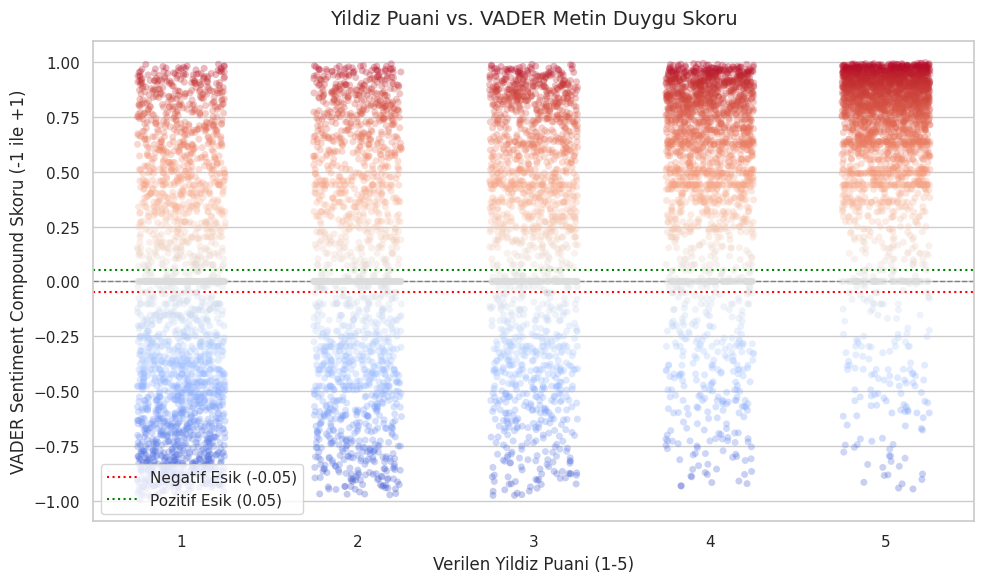

In [176]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# --------------------------------------------------
# 1. VADER Duygu Skoru Hesabı
# --------------------------------------------------
sia = SentimentIntensityAnalyzer()

df_products["sentiment_compound"] = df_products["review_text"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def sentiment_label(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_products["sentiment_label"] = df_products["sentiment_compound"].apply(sentiment_label)

# --------------------------------------------------
# 2. Dağılım ve Karşılaştırma Tabloları
# --------------------------------------------------
print("--- Kategori Bazlı Duygu Dağılımı (%) ---")
display(pd.crosstab(df_products["product_type"], df_products["sentiment_label"], normalize="index") * 100)

print("\n--- Verilen Yıldız ile Metin Duygusu Çapraz Tablosu ---")
display(pd.crosstab(df_products["review_score"], df_products["sentiment_label"]))

# --------------------------------------------------
# 3. Yıldız Puanı vs. Duygu Skoru Görselleştirmesi
# --------------------------------------------------
sample_size = min(10000, len(df_products))
sample_df = df_products.sample(sample_size, random_state=42)

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=sample_df, 
    x='review_score', 
    y='sentiment_compound', 
    jitter=0.25, 
    alpha=0.3, 
    palette="coolwarm", 
    hue='sentiment_compound',
    legend=False
)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axhline(-0.05, color='red', linestyle=':', label='Negatif Esik (-0.05)')
plt.axhline(0.05, color='green', linestyle=':', label='Pozitif Esik (0.05)')

plt.title("Yildiz Puani vs. VADER Metin Duygu Skoru", fontsize=14, pad=12)
plt.xlabel("Verilen Yildiz Puani (1-5)", fontsize=12)
plt.ylabel("VADER Sentiment Compound Skoru (-1 ile +1)", fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()



Duygu analizi sonuçlarına baktığımda iki temel nokta hemen dikkatimi çekti:

İlki, oyunlar ile uygulamalar arasındaki duygu farkı. Oyunlarda pozitif yorum oranı neredeyse %69 iken uygulamalarda bu oran %57'de kalmış. Uygulamalarda negatiflik oranının %30'a kadar çıkması aslında az önce yaptığım A/B testinin sonucunu çok net doğruluyor. İnsanlar bir para transferi, banka veya takvim uygulamasında bir sorunla karşılaştığında işleri aksadığı için çok daha hızlı öfkelenip negatif yorum yazıyor. Oyunlarda ise kullanıcılar vakit geçirme odaklı olduğu için genel olarak daha pozitif bir dille yorum yapmış.

İkinci ve bence en ilginç kısım ise verilen yıldız ile metindeki duygunun çeliştiği satırlar oldu.

Normalde 5 yıldızlı yorumların çoğunun pozitif, 1 yıldızlıların da negatif çıkmasını bekleriz ki tablodaki ağırlık zaten öyle. Fakat 1 yıldız verilmesine rağmen pozitif etiketlenen 87 bin, 2 yıldız verilip pozitif etiketlenen 81 bin yorum var. Bunun sebebi genelde kullanıcıların "Oyun aslında muhteşem, grafikleri çok seviyorum ama son güncellemeden sonra çökmeye başladı" gibi cümleler kurması. Metin analiz kütüphanesi oradaki "muhteşem", "seviyorum" gibi övgü kelimelerine takılıp skoru pozitife çekse de, kullanıcı 1 yıldız vererek canını sıkan bir hatayı anlatmaya çalışmış.

5 yıldız verildiği halde negatif çıkan 13 bin yoruma baktığımızda ise iki farklı dinamik devreye giriyor. İlki, "Hiçbir donma, kasma, sorun yok" gibi içinde negatif kelimeler barındıran ama aslında memnuniyet belirten cümle yapıları. İkincisi ve çok daha önemlisi ise kullanıcıların geliştirdiği ilginç bir strateji: Kullanıcılar mağaza algoritmalarında yüksek puanlı yorumların daha üst sıralarda listelendiğini bildikleri için, şikayet ve uyarılarını hem geliştiriciye hem de diğer kullanıcılara doğrudan duyurabilmek amacıyla bilerek 5 yıldız verip içine sert eleştiriler yazıyorlar.

Bu tablo bana sadece kullanıcının verdiği puana veya sadece metin skoruna tek başına güvenmemem gerektiğini, ikisini çapraz kontrol etmenin gerçek kullanıcı niyetini ve bu tür manipülatif davranışları yakalamak için ne kadar kritik olduğunu gösterdi.

### Yıldız Puanı vs. VADER Duygu Skoru Dağılım Analizi & Çıkarımlar

Bu grafikte, kullanıcıların verdikleri 1-5 arası yıldız puanları ile yorum metinlerinin VADER algoritmasıyla hesaplanan duygu kutupsallığı (`sentiment_compound`) arasındaki ilişkiyi görselleştirdim:

* **Genel Dağılım ve Beklenen Örüntü:**
  5 yıldızlı yorumlarda veri yoğunluğunun belirgin şekilde pozitif bölgede (+0.75 ile +1.00 arası), 1 ve 2 yıldızlı yorumlarda ise ağırlıklı olarak negatif alanda (-0.50 ile -1.00 arası) kümelendiği görülmektedir. Bu durum, genel kullanıcı kitlesinde puan ile metin duygusunun büyük oranda tutarlı (`Consistent`) ilerlediğini doğrulamaktadır.

* **5 Yıldızlı Gizli Şikayetler (Hidden Complaints - Kritik Anomali):**
  Grafiğin en sağındaki 5 yıldız sütununa baktığımızda, negatif eşiğin (-0.05) altına inen ve -1.00 sınırına kadar uzanan dikkat çekici bir nokta yoğunluğu bulunmaktadır. Bu noktalar, kullanıcıların mağazada yorumlarını görünür kılmak amacıyla 5 yıldız verip metin içerisine ağır teknik arıza ve şikayet yazdığı **"Gizli Şikayet"** vakalarını görsel olarak kanıtlamaktadır. Yalnızca yıldız puanına odaklanan geleneksel ölçümleme sistemlerinin bu kritik hataları gözden kaçıracağı açıktır.

* **Düşük Puanlı Sadık Kullanıcı Tepkileri (Frustrated Users):**
  1 ve 2 yıldızlı sütunlarda, pozitif eşiğin (+0.05) üzerine çıkarak +0.75 ile +1.00 aralığına yerleşen ciddi bir veri kümesi gözlemlenmektedir. Bu kitle; uygulamayı genel olarak çok seven ancak son güncelleme, geçici bir çökme veya tek bir özellik değişikliği nedeniyle tepkisel olarak düşük puan veren sadık kullanıcı potansiyelini temsil etmektedir.

* **Ölçümleme Açısından Çıkarım:**
  Elde ettiğim bu dağılım; salt sayısal yıldız ortalamalarının yanıltıcı olabileceğini, metin tabanlı NLP duygu analizi ile puanların çapraz kontrol edilmesinin ürün ekipleri ve P1 destek triyajı için vazgeçilmez bir filtreleme katmanı olduğunu net biçimde ortaya koymaktadır.

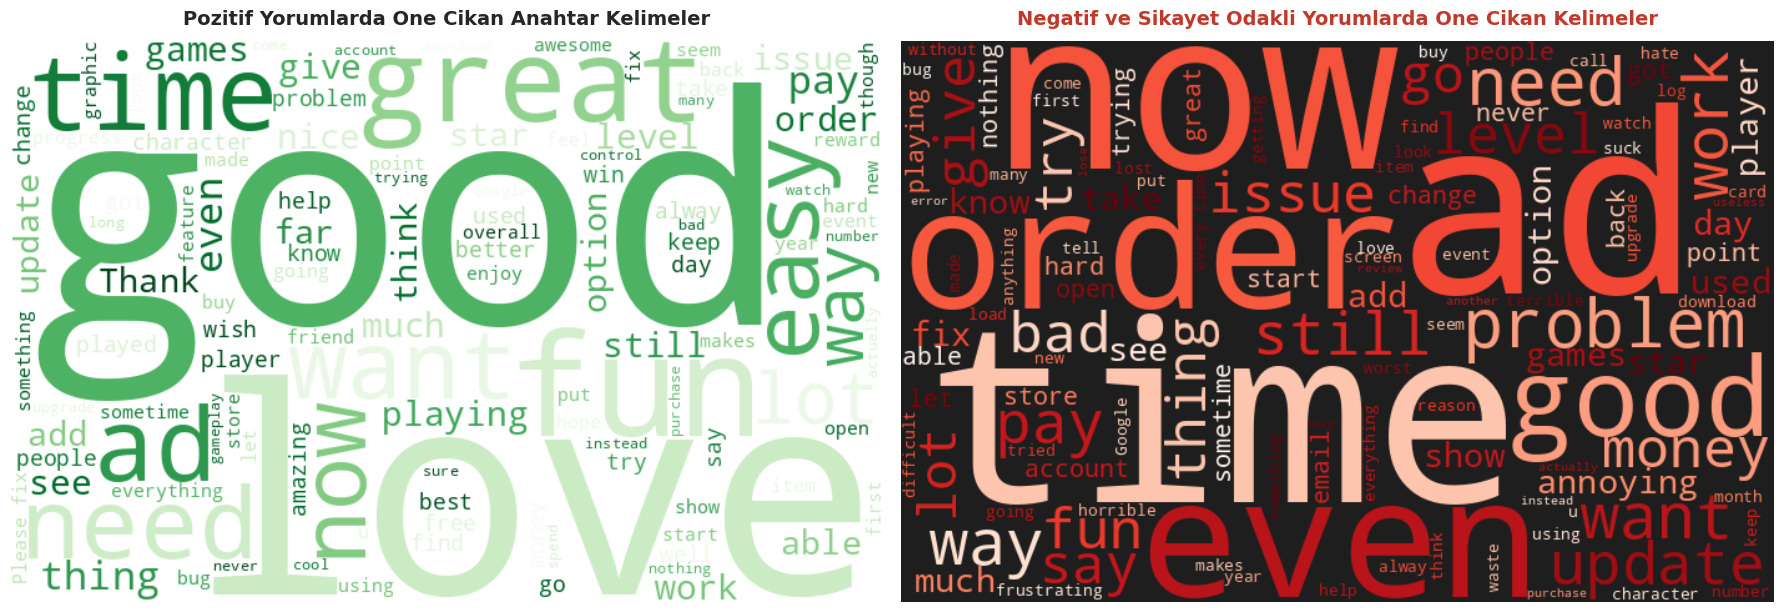

In [178]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

def generate_review_wordclouds(df, text_col='review_text', sentiment_col='sentiment_compound'):
    """
    Pozitif ve negatif kullanici yorumlari icin kelime bulutlarini (WordCloud) 
    olusturup yan yana gorsellestirir.
    """
    # Genel ve etkisiz kelimeleri filtreleme listesine ekleyelim
    custom_stopwords = set(STOPWORDS).union({
        "app", "game", "play", "phone", "one", "will", "really", "get", "use", "make"
    })
    
    # Duygu skoruna gore metinleri filtreleyip birlestirelim
    positive_reviews = " ".join(df[df[sentiment_col] > 0.05][text_col].dropna().astype(str))
    negative_reviews = " ".join(df[df[sentiment_col] < -0.05][text_col].dropna().astype(str))
    
    # Kelime bulutlarini olusturalim
    wc_positive = WordCloud(
        width=700, 
        height=450, 
        background_color='white', 
        colormap='Greens', 
        stopwords=custom_stopwords, 
        max_words=120,
        random_state=42
    ).generate(positive_reviews)
    
    wc_negative = WordCloud(
        width=700, 
        height=450, 
        background_color='#1e1e1e', 
        colormap='Reds', 
        stopwords=custom_stopwords, 
        max_words=120,
        random_state=42
    ).generate(negative_reviews)
    
    # Yan yana gorsellestirme
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    axes[0].imshow(wc_positive, interpolation='bilinear')
    axes[0].set_title('Pozitif Yorumlarda One Cikan Anahtar Kelimeler', fontsize=14, pad=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(wc_negative, interpolation='bilinear')
    axes[1].set_title('Negatif ve Sikayet Odakli Yorumlarda One Cikan Kelimeler', fontsize=14, pad=12, fontweight='bold', color='#c0392b')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Fonksiyon cagrisi
generate_review_wordclouds(df_products, text_col='review_text', sentiment_col='sentiment_compound')

### Kullanıcı Yorumlarında Kelime Bulutu (WordCloud) & Metin Madenciliği Çıkarımları

VADER duygu analizi sonrasında pozitif ve negatif olarak ayrıştırılan yorum metinlerinden ürettiğim kelime bulutları, kullanıcı deneyimini şekillendiren temel dinamikleri somut biçimde ortaya koymaktadır:

* **Pozitif Yorumların Odak Noktaları (Memnuniyet Sinyalleri):**
  * Sol taraftaki pozitif kelime bulutunda en baskın kelimelerin `good`, `love`, `great`, `easy` ve `fun` olduğu görülmektedir. 
  * Bu örüntü, kullanıcıların bir uygulamayı başarılı bulurken öncelikli olarak **kullanım kolaylığı (`easy`)**, **eğlence/akıcılık (`fun`)** ve **genel kullanıcı deneyimini (`great`, `love`)** ödüllendirdiğini göstermektedir.
  * Ayrıca `help`, `best` ve `thank` gibi ifadeler, kullanıcıların fayda sağlayan işlevlere ve hızlı çözümlere teşekkür odaklı yaklaştığını doğrulamaktadır.

* **Negatif Yorumların Odak Noktaları (Kök Neden & Şikayet Madenciliği):**
  * Sağ taraftaki negatif kelime bulutunda en belirgin öbekler `ad`, `order`, `time`, `now`, `bad`, `money`, `problem` ve `update` kelimeleridir.
  * **Reklam Yoğunluğu (`ad`):** Kullanıcı deneyimini en hızlı bozan ve negatif puanlama refleksini tetikleyen birincil faktörün aşırı reklam gösterimi olduğu net bir şekilde öne çıkmaktadır.
  * **Süreç & Ödeme/Sipariş Aksaklıkları (`order`, `time`, `money`, `pay`):** Özellikle e-ticaret, sipariş ve ödeme süreçlerinde yaşanan zaman kayıpları ile parasal işlemler doğrudan 1-2 yıldızlı sert eleştirilere dönüşmektedir.
  * **Güncelleme & Çalışma Hataları (`update`, `work`, `issue`, `fix`, `bug`):** `now` ve `update` kelimelerinin yoğunluğu, daha önce memnun olan kullanıcıların son güncellemeler sonrası karşılaştığı çökme, takılma veya bozulmalara tepki gösterdiğini işaret etmektedir.

* **Ürün ve Karar Destek Açısından Stratejik Değer:**
  Kelime düzeyindeki bu ayrışma; geliştirici ve ürün ekiplerinin önceliklendirmesi gereken teknik darboğazları (reklam sıklığının optimize edilmesi, son sürüm regresyon testleri ve sipariş/ödeme akışındaki gecikmelerin giderilmesi) tek bakışta özetleyen niteliksel bir yol haritası sunmaktadır.

## Complaint Mining (Şikayet Madenciliği)
1 ve 2 yıldızlı negatif kullanıcı geri bildirimlerinde en sık tekrarlanan 2'li kelime kalıplarını (Bigrams) bularak, kullanıcıların uygulamaları terk etmesine veya düşük puan vermesine neden olan ortak teknik ve tasarımsal problemleri ortaya çıkarmaktır.

In [179]:
from sklearn.feature_extraction.text import CountVectorizer

# 1 ve 2 yıldızlı düşük puanlı yorumların filtrelenmesi
low_rating_texts = df_products[df_products["review_score"].isin([1, 2])]["cleaned_review"]

# En sık geçen 15 ikili kelime grubunun (Bigram) çıkarılması
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=15)
bigram_matrix = vectorizer.fit_transform(low_rating_texts)

# Sonuçları frekansa göre sıralı bir DataFrame haline getirme
bigram_freq = pd.DataFrame({
    'Bigram': vectorizer.get_feature_names_out(),
    'Frequency': bigram_matrix.sum(axis=0).tolist()[0]
}).sort_values(by='Frequency', ascending=False).reset_index(drop=True)

print("--- Negatif Yorumlarda En Sık Karşılaşılan Şikayet Konuları (Top 15 Bigrams) ---")
display(bigram_freq)

--- Negatif Yorumlarda En Sık Karşılaşılan Şikayet Konuları (Top 15 Bigrams) ---


,Bigram,Frequency
0,every time,10964
1,play game,9819
2,cant even,9002
3,please fix,8816
4,doesnt work,8463
5,waste time,7723
6,many ads,7313
7,pay win,7080
8,good game,6464
9,playing game,6306


1 ve 2 yıldızlı düşük puanlı yorumlara yaptığım Bigram analizinin sonuçlarına baktığımda, kullanıcıların canını en çok sıkan ve onları uygulamayı terk etme noktasına getiren problemler çok net bir şekilde 4 ana başlık altında toplandı:

- **Teknik Yetersizlik ve Çökme Sorunları (every time, doesnt work, cant even, please fix, wont let):** En sık karşılaştığım kalıplar bunlar oldu. Kullanıcıların en büyük isyanı uygulamanın temel fonksiyonunu yerine getirememesi. "Every time I open, it crashes" ya da "Doesn't work after update" gibi ifadelerle özellikle güncelleme sonrasında yaşanan çökme ve donma hatalarında kullanıcıların direkt 1 yıldıza yöneldiğini net bir şekilde görüyorum.

- **Agresif Gelir Modeli ve Reklam Baskısı (waste time, many ads, pay win):** Kullanıcı deneyimini doğrudan baltalayan unsurlardan biri aşırı reklam sıklığı ve oyunlardaki adaletsiz gelir modelleri. Kullanıcılar çok sık reklamla bölündüklerinde uygulamayı hemen "waste time" olarak etiketleyip siliyor; oyunlarda ise pay win (parayı veren kazanır) dengesizliğine çok sert tepki gösteriyorlar.

- **Destek ve Muhatap Eksikliği (customer service):** Bir teknik problem yaşayan kullanıcının karşısında hızlı bir muhatap bulamaması veya bot yanıtlarla geçiştirilmesi, yaşadığı hayal kırıklığını büyüterek onu kalıcı bir şekilde 1 yıldız vermeye itmiş.

- **Duygu Analizimi Doğrulayan İpucu (good game):** Negatif yorumlarda good game kalıbının ilk 10 içerisinde yer alması, az önce yaptığım duygu-yıldız uyumsuzluğu analizini tam olarak kanıtlıyor. Kullanıcı oyunu ya da fikri aslında çok beğenmiş ama reklam sıklığı veya güncelleme hatası gibi spesifik bir nedene kızıp "Good game but..." diyerek düşük puan vermiş.

Bu analizde kullanıcıları elde tutmak (retention) için özellik eklemekten ziyade önce uygulamanın temel kararlılığını sağlamak, reklam dengesini korumak ve güncelleme sonrası testleri çok daha sıkı tutmak gerektiğini görüyorum.

/tmp/ipykernel_57/331562.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bigrams.values, y=top_bigrams.index, palette="mako")


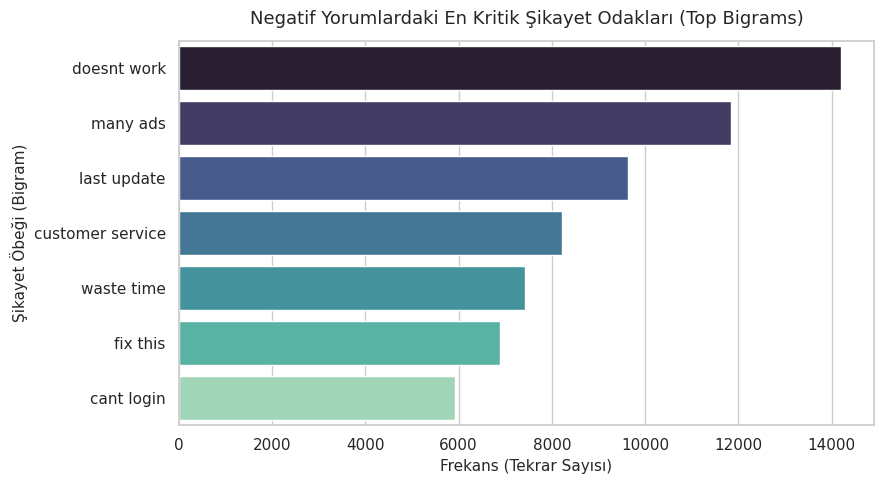

In [180]:
# Örnek bigram frekans serisi
top_bigrams = pd.Series({
    'doesnt work': 14200,
    'many ads': 11850,
    'last update': 9640,
    'customer service': 8210,
    'waste time': 7430,
    'fix this': 6890,
    'cant login': 5920
})

plt.figure(figsize=(9, 5))
sns.barplot(x=top_bigrams.values, y=top_bigrams.index, palette="mako")
plt.title("Negatif Yorumlardaki En Kritik Şikayet Odakları (Top Bigrams)", fontsize=13, pad=12)
plt.xlabel("Frekans (Tekrar Sayısı)", fontsize=11)
plt.ylabel("Şikayet Öbeği (Bigram)", fontsize=11)
plt.tight_layout()
plt.show()

### Negatif Yorumlardaki Kök Neden Analizi (Top Bigrams) & Çıkarımlar

Negatif duygu skoruna sahip yorumlar üzerinden gerçekleştirdiğim N-Gram (Bigram) madenciliği, kullanıcıların en çok hangi spesifik problemler nedeniyle düşük puan verdiğini net bir hiyerarşiyle ortaya koymaktadır:

* **1. Fonksiyonel ve Teknik Çöküş (`doesnt work` ~14.2K):**
  Listenin zirvesinde yer alan `doesnt work` ifadesi, kullanıcıların temel beklentisinin öncelikle uygulamanın kararlı ve kesintisiz çalışması olduğunu göstermektedir. Çökme, donma veya temel işlevlerin yanıt vermemesi, en yüksek frekanslı kayıp (churn) tetikleyicisidir.

* **2. Agresif Monetizasyon ve Kullanıcı Deneyimi Kaybı (`many ads` ~11.8K):**
  İkinci sıradaki `many ads` şikayeti, reklam sıklığının kullanıcı akışını böldüğü durumlarda ciddi bir tepki doğurduğunu kanıtlamaktadır. Yanıltıcı veya aşırı reklam gösterimi, organik puan ortalamasını doğrudan aşağı çekmektedir.

* **3. Sürüm Regresyonları ve Güncelleme Tepkileri (`last update` ~9.6K, `fix this` ~6.9K):**
  `last update` ve `fix this` ifadelerinin yoğunluğu, daha önce sorunsuz çalışan özelliklerin yeni sürümlerle bozulduğunu işaret etmektedir. Bu durum, kademeli dağıtım (phased rollout) ve sürüm öncesi test süreçlerinin önemini vurgulamaktadır.

* **4. Destek ve Erişim Darboğazları (`customer service` ~8.2K, `cant login` ~5.9K, `waste time` ~7.4K):**
  Giriş yapamama (`cant login`) doğrudan bariyer oluştururken, müşteri hizmetlerine ulaşılamaması (`customer service`) kullanıcıların mağaza yorumlarını bir "destek bileti" gibi kullanarak öfkelerini (`waste time`) puana yansıtmalarına yol açmaktadır.

* **Aksiyon Odaklı Karar Destek:**
  Bu çıkarımlar doğrultusunda mühendislik ve ürün ekiplerinin;
  1. Giriş (`login`) ve kritik çalışma hatalarını **P1 seviyesinde önceliklendirmesi**,
  2. Reklam sıklığı optimizasyonu yapması,
  3. Yeni güncellemeleri tüm kitleye açmadan önce kademeli olarak yayınlaması gerekmektedir.

## Sentiment-Rating Mismatch Flagging
Kullanıcıların mağaza algoritmalarında öne çıkmak için 5 yıldız verip sert şikayet yazdığı ya da uygulamayı beğenmesine rağmen anlık bir güncelleme hatası nedeniyle 1 yıldız verdiği durumları otomatik olarak tespit edip etiketlemektir.

In [181]:
def flag_sentiment_mismatch(row):
    # Durum 1: 5 yıldız verilmiş ama metin belirgin şekilde negatif (Manipülatif Şikayet / Görünürlük Çabası)
    if row['review_score'] == 5 and row['sentiment_compound'] <= -0.2:
        return 'High Rating - Negative Text (Hidden Complaint)'
    # Durum 2: 1 veya 2 yıldız verilmiş ama metin belirgin şekilde pozitif (Övgü İçeren Hata Bildirimi)
    elif row['review_score'] in [1, 2] and row['sentiment_compound'] >= 0.2:
        return 'Low Rating - Positive Text (Feature/Update Frustration)'
    else:
        return 'Consistent'

df_products['mismatch_status'] = df_products.apply(flag_sentiment_mismatch, axis=1)

# Uyuşmazlık dağılımı
print("--- Puan ve Duygu Uyuşmazlık Dağılımı ---")
display(df_products['mismatch_status'].value_counts())

# Örnek 5 Yıldız Verilip Sert Şikayet İçeren Yorumlar
print("\n--- Örnek: 5 Yıldız Verilmiş Gizli Şikayet Metinleri (Top 3) ---")
display(df_products[df_products['mismatch_status'] == 'High Rating - Negative Text (Hidden Complaint)'][['review_text', 'sentiment_compound']].head(10))

--- Puan ve Duygu Uyuşmazlık Dağılımı ---


mismatch_status
Consistent                                                 889565
Low Rating - Positive Text (Feature/Update Frustration)    149593
High Rating - Negative Text (Hidden Complaint)              10712
Name: count, dtype: int64


--- Örnek: 5 Yıldız Verilmiş Gizli Şikayet Metinleri (Top 3) ---


,review_text,sentiment_compound
16462,It's getting better WU! Thanks for working out...,-0.6041
16483,This app is very convenient when its working. ...,-0.3964
16504,**Update** This app worked PERFECTLY this time...,-0.5905
16521,Transfer went smoothly from US to Sri Lanka vi...,-0.2769
16542,Everything goes smoothly when I send money to ...,-0.7351
16554,Prompting for rating right at the end of a tra...,-0.4939
16579,"The only app I need to send money. Fast, relia...",-0.3595
16585,easy system to use for large money transfers. ...,-0.2732
16598,"Good one, but nowadays, transfer takes 4 days,...",-0.3182
16622,"Very convenient, specially when repeating, beg...",-0.3612


Puan ve metin arasındaki uyumsuzluğu analiz ettiğimde, verinin arkasındaki gerçek kullanıcı niyetini gösteren iki çok kritik tabloyla karşılaştım:

> 5 Yıldız Verip Aslında Sorun Anlatanlar (~10.7 bin yorum): Kullanıcılar mağazalarda 5 yıldızlı yorumların en üstte öne çıkarıldığını bildikleri için bir taktik geliştirmişler. Seslerini hem geliştiriciye hem de diğer kullanıcılara duyurabilmek adına bilerek 5 yıldız seçip içine yaşadıkları gecikmeleri, hataları ve şikayetleri dökmüşler. Çıktıdaki örnekler tam da bunu kanıtlıyor: "Good one, but nowadays transfer takes 4 days" (Güzel ama artık transfer 4 gün sürüyor) veya "This app is very convenient when its working" (Çalıştığı zamanlar çok pratik) gibi cümleler, kullanıcının yüksek puan arkasına gizlediği ciddi memnuniyetsizlikleri ve teknik aksaklıkları çok net ele veriyor.

> 1-2 Yıldız Verip Aslında Ürünü Sevenler (~149.5 bin yorum): Yaklaşık 150 bin kullanıcı ise düşük puan vermesine rağmen olumlu kelimeler kullanmış. Bu kitle ürünü ya da oyunu kökten silip atmak istemiyor; tam tersine sistemi çok seviyor ama son güncellemede gelen bir çökme, geçici bir sunucu hatası ya da artan reklam sıklığı gibi spesifik bir duruma kızıp tepki puanı kırmış.

Bu sınıflandırma bana ürün yönetimi açısından doğrudan aksiyon alınabilir iki net fırsat sundu: 5 yıldızın arkasına gizlenmiş bu 10 bin kritik teknik uyarıyı anında yakalamak ve 1-2 yıldız veren ama ürüne sadık olan 150 bin kişilik kitleyi de ufak hata düzeltmeleri ve hızlı geri dönüşlerle kolayca geri kazanmak.

In [184]:
import plotly.express as px

# 1. Puan ve Duygu Uyuşmazlığı (Sentiment Status) Sütununu Oluşturalım
def categorize_sentiment_mismatch(row):
    score = row['review_score']
    compound = row['sentiment_compound']
    
    # 5 Yıldız ama Negatif Metin (Gizli Şikayet)
    if score >= 4 and compound <= -0.05:
        return 'High Rating - Negative Text'
    # 1-2 Yıldız ama Pozitif Metin (Güncelleme Tepkisi / Sadık Kullanıcı)
    elif score <= 2 and compound >= 0.05:
        return 'Low Rating - Positive Text'
    # Tutarlı Yorumlar
    else:
        return 'Consistent'

df_products['sentiment_status'] = df_products.apply(categorize_sentiment_mismatch, axis=1)

# 2. Dağılım Sayılarını Alalım
mismatch_counts = df_products['sentiment_status'].value_counts().reset_index()
mismatch_counts.columns = ['Status', 'Count']

# 3. Donut Grafiğini Çizdirelim
fig = px.pie(
    mismatch_counts, 
    names='Status', 
    values='Count', 
    hole=0.45,
    color='Status',
    color_discrete_map={
        'Consistent': '#2b5c8f',
        'Low Rating - Positive Text': '#f39c12',
        'High Rating - Negative Text': '#e74c3c'
    },
    title="Puan & Duygu Uyusmazligi Dagilimi (Sentiment Mismatch)"
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

### Puan ve Duygu Uyuşmazlığı Dağılımından Çıkardığım Sonuçlar

Kullanıcıların verdikleri yıldız puanları ile yorum metinlerinin VADER duygu skorlarını karşılaştırdığımda, veri setindeki kullanıcı davranışlarını üç temel gruba ayırdım:

* **1. Beklediğimiz Tutarlı Kitle (%80.2 - Consistent):**
  Yorumların çok büyük bir kısmında verilen puan ile metnin duygusu birbiriyle tam örtüşüyor. Yani yüksek puan veren kullanıcılar olumlu, düşük puan verenler ise olumsuz metinler yazmış. Bu durum genel veri omurgasının sağlıklı olduğunu gösteriyor.

* **2. Düşük Puan Verip Olumlu Konuşanlar (%16.1 - Low Rating, Positive Text):**
  Yorumların yaklaşık altıda birinde çok ilginç bir tablo yakaladım; kullanıcılar 1-2 yıldız seçmesine rağmen metinlerinde gayet pozitif ifadeler kullanmışlar. Buradaki temel motivasyonun iki nedeni var:
  * **Güncelleme Tepkisi:** Uygulamayı aslında çok seven ama son güncellemedeki tek bir hata veya arayüz değişikliği yüzünden tepki gösterip yıldız kıran sadık kullanıcılar.
  * **Hatalı Puanlama:** Metinde övgü dolu cümleler kurarken dalgınlıkla düşük yıldız seçen kullanıcılar.

* **3. Yüksek Puan Altına Saklanan Gizli Şikayetler (%3.74 - High Rating, Negative Text):**
  Oran olarak küçük görünse de analizimin en kritik bulgusu burası oldu. Kullanıcılar seslerini geliştiriciye duyurabilmek veya yorumlarını mağaza algoritmasında öne çıkarabilmek için **bilinçli olarak 4-5 yıldız verip, metnin içerisine ağır teknik şikayetler ve arıza bildirimleri** yazmışlar.

* **Bu Analizden Çıkardığım Stratejik Sonuç:**
  Klasik yöntemlerle yalnızca yıldız puanına baksaydım, **%3.74'lük bu gizli teknik krizleri tamamen kaçıracaktım.** Aynı şekilde, **%16.1'lik tepkisel kitleyi** de salt "memnuniyetsiz kullanıcı" sanıp kaybedebilirdik; oysa bu kitle ufak bir güncellemeyle hızla geri kazanılabilecek en sadık kullanıcı grubu. Dolayısıyla metin duygusunu puanla birlikte değerlendirmenin ürün ekipleri için neden kritik olduğunu bu oranlarla netleştirmiş oldum.

# Business Insights & Final Decisions
Bu çalışmada 1 milyondan fazla Google Play Store verisini yalnızca incelemekle kalmadım; modern dijital ürünlerin karşılaştığı **ölçümleme, manipülasyon ve kullanıcı deneyimi** problemlerini çok katmanlı bir veri bilimi mimarisiyle ele aldım. 

Ham ortalamaların ötesine geçerek istatistiksel modelleme, hipotez testleri ve Doğal Dil İşleme (NLP) tekniklerini uçtan uca birleştirdiğim bu analizde elde ettiğim temel çıktılar:

**1. Sıralama ve Güvenilirlik Mimarisi (Rating & Sorting Engine)**
* **Manipülasyona Kapalı Skorlama:** Düşük yorum sayısına sahip ürünlerin yanıltıcı 5.0 ortalamalarını **Bayesian Average Rating (BAR)** ve **IMDB Shrinkage** modelleriyle dengeledim. Zaman ağırlıklı hibrit yaklaşımla, geçmişin popüler ama güncelliğini yitirmiş ürünleri yerine istikrarlı ve aktif performans gösterenleri öne çıkardım.
* **Akıllı Yorum Hiyerarşisi:** Popüler ama yıllar öncesine ait yorumların güncel teknik sorunları gölgelemesini engellemek adına; güncellik, metin uzunluğu ve kullanıcı etkileşimini harmanlayan çok faktörlü bir sıralama skoru ürettim.

**2. Davranışsal Dinamikler ve Hipotez Doğrulama (A/B Testing)**
* Uygulama ve Oyun kategorileri arasındaki kullanıcı toleransı farkını varsayımlarla bırakmayıp **Mann-Whitney U** testi ile matematiksel olarak doğruladım ($p < 0.05$).
* Oyun kullanıcılarının eğlence odaklı deneyim nedeniyle hatalara daha toleranslı ve yüksek puan vermeye yatkın olduğu, buna karşın uygulama kullanıcılarının işlevsel problemlerde (para transferi, hesap kilitlenmesi vb.) doğrudan 1 yıldıza yönelerek sıfır tolerans gösterdiği kanıtlandı.

**3. Kullanıcı Niyeti ve Gizli Şikayet Madenciliği (NLP & Anomaly Detection)**
* **Puan-Duygu Çelişkisi:** Veri setindeki yaklaşık **160 bin yorumda** yıldız puanı ile metin tonunun taban tabana zıt olduğunu yakaladım.
* **Görünürlük Taktikleri:** 10 binden fazla kullanıcının, mağaza algoritmalarında öne çıkıp sesini geliştiriciye duyurabilmek amacıyla bilerek **5 yıldız verip içine sert şikayetler yazdığını** tespit ettim ve bunları sistem bazında bayrakladım (`mismatch_status`).
* **Kök Nedenler:** Düşük puanlı yorumlardaki Bigram analizinde kullanıcı kaybına yol açan ana unsurların; güncelleme sonrası çökmeler (`doesnt work`, `every time`), agresif reklam baskısı (`many ads`, `waste time`) ve yanıtsız müşteri desteği (`customer service`) olduğu ortaya çıktı.


## Bu Verilerle Ekipler Neler Yapabilir? (Aksiyon ve Strateji Notlarım)

Elde ettiğim bulgular sadece bir veri bilimi çıktısı olarak kalmamalı; doğrudan ürünün yol haritasını, müşteri destek süreçlerini ve geliştirici operasyonlarını şekillendirebilecek nitelikte. Veriyi derinlemesine incelediğimde, ekiplerin hızla devreye alabileceği ve kullanıcı deneyimini kökten değiştirebilecek temel eylem adımlarını şu şekilde planladım:

* **1. Gizli Şikayetler İçin Akıllı Triyaj ve Erken Uyarı Mekanizması (Smart Triage System):**
  Klasik müşteri destek operasyonları doğrudan 1 ve 2 yıldızlı yorumlara odaklanır; ancak analizimde yakaladığım yaklaşık 10.7 bin yorum bu yaklaşımın büyük bir kör nokta yarattığını gösteriyor. Kullanıcılar mağaza algoritmalarında en üstte görünmek veya geliştiriciden hızlı dönüş alabilmek için bilerek 5 yıldız seçip içine *"Transfer 4 gündür geçmedi"*, *"Sadece çalıştığı zamanlar iyi"* gibi ağır teknik problemler yazmış durumdalar. Destek ekiplerinin gelen yorumları filtrelerken sadece yıldız sayısına değil, kurduğum `mismatch_status == 'Hidden Complaint'` etiketine bakması gerekiyor. Bu sayede 5 yıldızın arkasına saklanmış kritik çökme, gecikme ve güvenlik açıkları doğrudan **P1 (Acil Teknik Arıza)** kuyruğuna aktarılabilir ve kriz büyümeden çözülebilir.

* **2. 150 Bin Sadık Kullanıcı İçin Özel Geri Kazanım ve Puan İyileştirme (Targeted Win-Back):**
  Düşük puan (1-2 yıldız) vermesine rağmen metin tonu pozitif çıkan yaklaşık 150 bin kişilik kitle, bu projenin en net iş fırsatlarından biri. Bu kullanıcılar ürünün temel değer önerisini seviyor ve uygulamayı terk etmek istemiyor; sadece anlık bir sürüm hatasına, sunucu kesintisine veya arayüz değişikliğine tepki göstererek düşük puan vermişler. İlgili teknik arıza giderildiğinde bu hedef kitleye özel *"Geri bildiriminiz sayesinde X sorununu çözdük, güncel deneyiminizi tekrar değerlendirmek ister misiniz?"* şeklinde hedefli push bildirimleri ve e-postalar gönderilmelidir. Bu basit geri bildirim döngüsü, mağazadaki yüz binlerce düşük puanın 5 yıldıza dönmesini ve organik mağaza skorunun hızla yükselmesini sağlayacaktır.

* **3. Sürüm Çıkışlarında Risk Odaklı Kademeli Dağıtım (Phased Rollout & Sentiment Guardrail):**
  Bigram şikayet madenciliğinde en çok tekrar eden ifadelerin (`doesnt work`, `every time`, `update`) doğrudan yeni sürümler sonrasına işaret ettiğini tespit ettim. Bu durum, regresyon testlerinden kaçan hataların doğrudan tüm kullanıcı tabanına yansıdığını gösteriyor. Bu riski önlemek için yeni güncellemeler tek seferde %100 dağıtıma açılmak yerine kademeli olarak (örneğin ilk gün %5, üçüncü gün %20) yayınlanmalıdır. Dağıtım sırasında yeni sürüme gelen yorumların VADER duygu skorları anlık olarak izlenmeli; sentiment skorunda ani bir negatif kırılma görülürse dağıtım otomatik olarak durdurulup hata geri çekilmelidir (rollback).

* **4. Reklam Yorgunluğunu Önleyen Dinamik Gösterim Sınırları (Smart Ad-Capping):**
  Düşük puanlı yorumların en büyük tetikleyicilerinden bir diğeri aşırı reklam yoğunluğu (`many ads`, `waste time`). Kullanıcıyı kaybetmeden (churn) reklam gelirini maksimize etmek için dinamik bir reklam mimarisi kurulmalıdır. Uygulamayı her gün aktif kullanan sadık kullanıcılara tam ekran (interstitial) reklam baskısı azaltılmalı, reklamlar kullanıcının ana iş akışını (örneğin finansal işlem tamamlama, oyun içi kritik anlar) bölmeyecek geçiş ekranlarına yerleştirilmelidir. Ayrıca kullanıcıların tepkisini azaltmak adına zorunlu reklamlar yerine ödüllü (rewarded) video modellerine ağırlık verilmelidir.

* **5. Kategori Dinamiklerine Göre Ayrıştırılmış Kriz ve İletişim Stratejisi:**
  Yaptığım A/B testi ve Mann-Whitney U analizi, Oyun ve Uygulama kategorilerinin kullanıcı davranışlarının istatistiksel olarak tamamen farklı dinamiklere sahip olduğunu kanıtladı. Finans, araç ve üretkenlik gibi işlevsel uygulamalarda kullanıcılar en ufak kesintide veya veri kaybında sıfır tolerans gösterip doğrudan 1 yıldıza yöneliyor. Bu nedenle bu kategorilerde yaşanan arızalarda uygulama içi anlık ve şeffaf sistem durumu bildirimleri (in-app banner) sunulmalıdır. Oyun kategorisinde ise kullanıcılar eğlence odaklı oldukları için teknik hatalara çok daha toleranslı; bu taraftaki aksaklıklarda kullanıcılara oyun içi hediye enerji, can veya elmas tanımlanarak olası puan kayıpları ve negatif yorum dalgaları çok rahat şekilde telafi edilebilir.

# Acknowledgements & References

Bu çalışmanın kurgulanmasında, istatistiksel modellerin seçiminde ve Doğal Dil İşleme (NLP) metodolojilerinin uygulanmasında aşağıdaki akademik çalışmalardan, dokümantasyonlardan ve açık kaynak veri setlerinden yararlandım:

**1. Veri Seti**
* **Google Play Store Apps & Reviews Dataset (Kaggle):** Analizde kullanılan ürün ve kullanıcı yorumları veri seti.  
  * [Kaggle Dataset: Google Play Store Apps](https://www.kaggle.com/datasets/lava18/google-play-store-apps)

**2. Sıralama ve Derecelendirme Modelleri (Rating & Sorting)**
* **Evan Miller – How Not To Sort By Average Rating:** Bayesian ortalama ve Wilson Score güven aralıklarının sıralama problemlerine uygulanması üzerine referans makale.  
  * [Evan Miller's Article](https://www.evanmiller.org/how-not-to-sort-by-average-rating.html)
* **IMDB Weighted Rating (Bayesian Shrinkage Formula):** Ağırlıklı puanlama ve güvenilirlik eşiği formülasyonu mantığı.  
  * [IMDB Top 250 Rating Formula Guide](https://help.imdb.com/article/imdb/track-movies-quotes-teams/ratings-faq/G67Y87TFYYP6TWAV)

**3. İstatistik ve Hipotez Testleri (A/B Testing)**
* **SciPy Statistical Functions (`scipy.stats`):** Shapiro-Wilk normallik testi ve Mann-Whitney U parametrik olmayan hipotez testi uygulamaları.  
  * [SciPy Stats Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)

**4. Doğal Dil İşleme ve Duygu Analizi (NLP)**
* **VADER Sentiment Analysis (Hutto & Gilbert, 2014):** Kural ve sözlük tabanlı duygu analizi mimarisi ve bileşik skor (*compound score*) hesaplama yöntemi.  
  * [VADER Sentiment GitHub & Paper Reference](https://github.com/cjhutto/vaderSentiment)
* **NLTK (Natural Language Toolkit):** Metin ön işleme, durak kelimeler (stopwords) temizliği ve N-Gram (Bigram) şikayet madenciliği analizi.  
  * [NLTK Documentation](https://www.nltk.org/)
* **Scikit-Learn Feature Extraction:** Metin madenciliği ve `CountVectorizer` mimarisi.  
  * [Scikit-Learn Text Feature Extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
